# LOAN DEFAULT PREDICTION #

## Problem Definition ##

#### The Context ####

A major proportion of retail bank profit comes from interest on home equity loans. These loans are borrowed by regular and high-earning customers, and bad loans (non-performing assets) represent a significant threat to bank profitability. The loan approval process is currently effort-intensive and prone to human error and bias, making it both inefficient and inconsistent. With the advancement of data science and machine learning, there is an opportunity to automate and standardize this process — building a model that is free of human bias while remaining compliant with the Equal Credit Opportunity Act (ECOA), which requires that any adverse credit decision be empirically justified.

#### The Objective ####

The objective of this project is to build a binary classification model that accurately predicts which home equity loan applicants are likely to default on their loan. The model must be interpretable enough to provide justification for adverse credit decisions in compliance with ECOA guidelines, and should prioritize recall as the primary success metric — ensuring that the maximum number of actual defaulters are identified before loan approval.

#### The Key Questions ####

1) Which borrower characteristics are the strongest predictors of loan default?

2) How do credit behavior variables such as delinquency history and derogatory marks compare to financial size variables such as loan amount and property value in predicting default risk?

3) Can a machine learning model reliably identify defaulters while maintaining acceptable precision — minimizing both missed defaults and incorrect rejections of creditworthy applicants?

4) Which features should the bank prioritize during the underwriting process to improve loan portfolio quality?

5) How can the model's predictions be made interpretable and explainable to comply with fair lending regulations such as ECOA?

#### The Problem Formulation ####

This is a supervised binary classification problem. The target variable BAD takes a value of 1 when a borrower has defaulted or been severely delinquent on their home equity loan, and 0 when the loan has been successfully repaid. Using 12 input variables covering borrower demographics, credit history, financial obligations, and employment information, the goal is to train a machine learning model that can predict the probability of default for new loan applicants based on patterns learned from historical data. The model's performance will be evaluated primarily on Recall (the proportion of actual defaulters correctly identified) as missing a genuine defaulter carries a significantly higher financial cost to the bank than incorrectly flagging a low-risk applicant for additional review.

### Data Description ###

Data Description:

The Home Equity dataset (HMEQ) contains baseline and loan performance information for 5,960 recent home equity loans. The target (BAD) is a binary variable that indicates whether an applicant has ultimately defaulted or has been severely delinquent. This adverse outcome occurred in 1,189 cases (20 percent). 12 input variables were registered for each applicant.

BAD: 1 = Client defaulted on loan, 0 = loan repaid

LOAN: Amount of loan approved.

MORTDUE: Amount due on the existing mortgage.

VALUE: Current value of the property.

REASON: Reason for the loan request. (HomeImp = home improvement, DebtCon= debt consolidation which means taking out a new loan to pay off other liabilities and consumer debts)

JOB: The type of job that loan applicant has such as manager, self, etc.

YOJ: Years at present job.

DEROG: Number of major derogatory reports (which indicates a serious delinquency or late payments).

DELINQ: Number of delinquent credit lines (a line of credit becomes delinquent when a borrower does not make the minimum required payments 30 to 60 days past the day on which the payments were due).

CLAGE: Age of the oldest credit line in months.

NINQ: Number of recent credit inquiries.

CLNO: Number of existing credit lines.

DEBTINC: Debt-to-income ratio (all your monthly debt payments divided by your gross monthly income. This number is one way lenders measure your ability to manage the monthly payments to repay the money you plan to borrow.

### Library and Data Import ###

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation Metrics
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, 
recall_score, f1_score, roc_auc_score)

# Model Selection & Tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# SHAP for model interpretability
import shap

In [241]:
# Uploading the csv data file
data = pd.read_csv("data/hmeq.csv")
data

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882


In [242]:
# Making a copy of the dataframe
df = data.copy()
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


Upon first glance at the dataset, it is evident that several records contain missing values across various columns.

### Summary Statistics ###

In [243]:
# Getting the general info about the dataset and columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   str    
 5   JOB      5681 non-null   str    
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), str(2)
memory usage: 605.4 KB


In [244]:
# Confirming the number of missing values for each column
df.isnull().sum()

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

In [245]:
# Percent of the missing values for each columns

round((df.isnull().sum() / len(df)) * 100, 2)

BAD         0.00
LOAN        0.00
MORTDUE     8.69
VALUE       1.88
REASON      4.23
JOB         4.68
YOJ         8.64
DEROG      11.88
DELINQ      9.73
CLAGE       5.17
NINQ        8.56
CLNO        3.72
DEBTINC    21.26
dtype: float64

From the column statistics, we can see that most columns are numerical — integers and floats, while JOB and REASON are string (categorical) columns. Several columns contain missing values, most notably DEBTINC (21.26%), DEROG (11.88%), and MORTDUE (8.69%), which will need to be addressed during data preprocessing.

In [246]:
# Checking for duplicated values
df.duplicated().sum()

np.int64(0)

The dataset contains no duplicate rows, confirming that all 5,960 records represent unique loan applicants.

In [247]:
# Getting the statistics
df.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


Summary statistics reveal that DEBTINC has an extreme maximum value of 203%, suggesting the presence of outliers. DEROG and DELINQ are heavily right-skewed, with most borrowers showing zero derogatory marks or delinquencies. The target variable BAD shows a class imbalance: approximately 20% of borrowers defaulted, which must be accounted for during model building.

## EDA Analysis ##

Before starting the analysis, I will separate all numerical and categorical columns into two distinct variables for simplicity and reusability throughout the analysis.

In [248]:
# Separating numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols

['BAD',
 'LOAN',
 'MORTDUE',
 'VALUE',
 'YOJ',
 'DEROG',
 'DELINQ',
 'CLAGE',
 'NINQ',
 'CLNO',
 'DEBTINC']

Since BAD is the target variable representing loan default outcome, it will be excluded from the numerical features list to avoid analyzing it as a regular input variable.

In [249]:
numerical_cols = [col for col in numerical_cols if col != 'BAD']
numerical_cols

['LOAN',
 'MORTDUE',
 'VALUE',
 'YOJ',
 'DEROG',
 'DELINQ',
 'CLAGE',
 'NINQ',
 'CLNO',
 'DEBTINC']

In [250]:
# Separating numerical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

['REASON', 'JOB']

### Univariate Analysis ###

In [251]:
# Creting a function to process the univariate analysis of each numerical column
def hist_boxplot(data, feature, bins=None, figsize=(9,7)):
    fig, (ax_box, ax_hist) = plt.subplots(nrows=2, sharex=True, figsize=figsize)
    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color='violet')

    if bins is None:
        sns.histplot(data=data, x=feature, ax=ax_hist, kde=True, color='green')
    else:
        sns.histplot(data=data, x=feature,ax=ax_hist, kde=True, color='red', bins=bins)

    ax_hist.axvline(data[feature].mean(), color='black', linestyle='--', label='Mean')
    ax_hist.axvline(data[feature].median(), color='blue', linestyle='-', label='Median')
    ax_hist.legend()

    plt.tight_layout()
    plt.show()

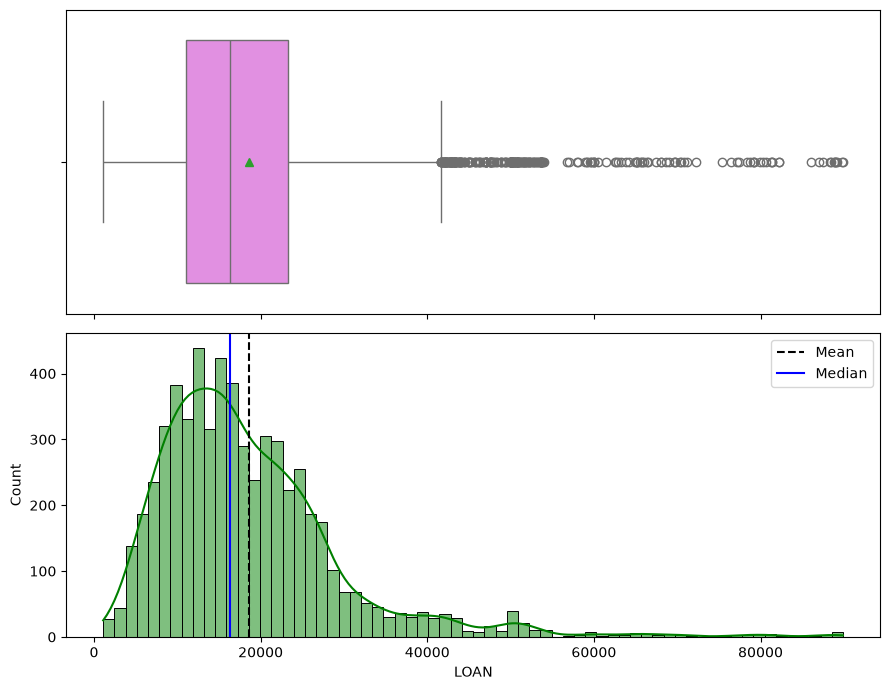

In [252]:
hist_boxplot(df, 'LOAN')

The LOAN distribution is right-skewed, with a long tail extending toward higher loan amounts. The boxplot reveals numerous outliers on the upper end, however, these likely represent legitimate high-value loans rather than data errors, as loan amounts naturally vary across applicants. The mean ($18,000) and median ($16,000) are relatively close to each other, suggesting the skew is moderate and the distribution does not require aggressive outlier treatment.

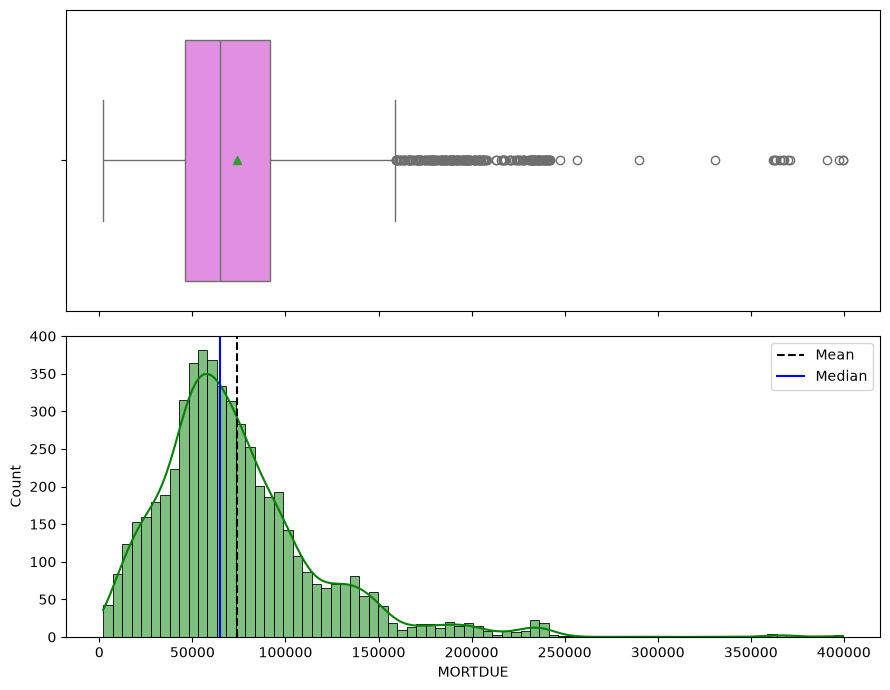

In [253]:
hist_boxplot(df, 'MORTDUE')

The MORTDUE distribution is right-skewed, indicating that most applicants have existing mortgage balances concentrated in the $50,000–$100,000 range, with a mean of $73,000 and median of $65,000. The gap between the mean and median confirms the right skew caused by a number of high-value mortgages. However, given that property values naturally vary and high mortgage balances are common in real estate, these outliers are likely legitimate and do not require treatment.

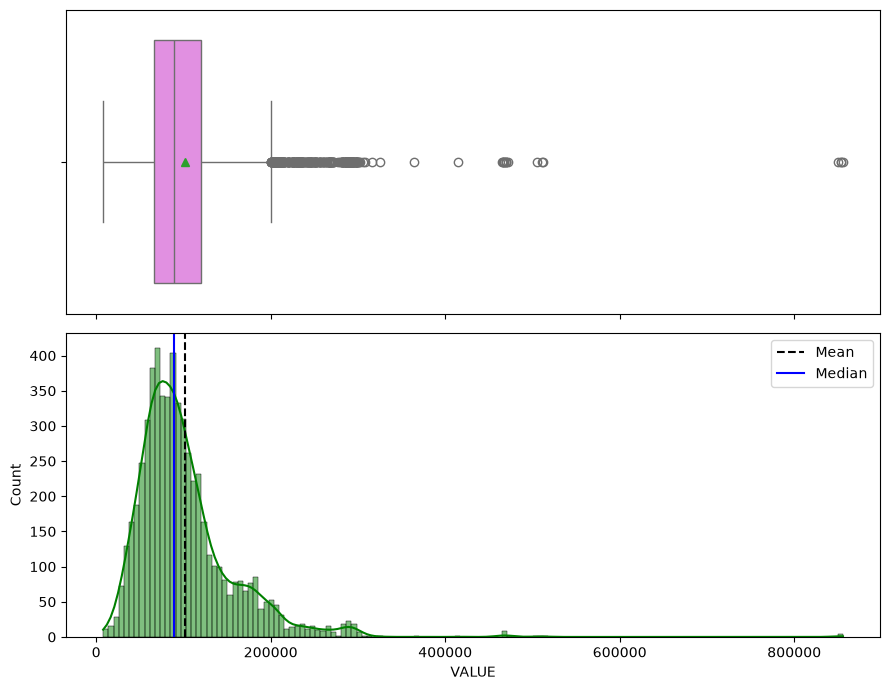

In [254]:
hist_boxplot(df, 'VALUE')

The VALUE distribution is heavily right-skewed, with most property values concentrated below $200,000. The mean ($102,000) is notably higher than the median ($89,000), confirming the skew driven by a small number of very high-value properties reaching up to $856,000. As with LOAN and MORTDUE, these outliers reflect the natural variation in real estate values rather than data errors, and therefore do not require treatment.

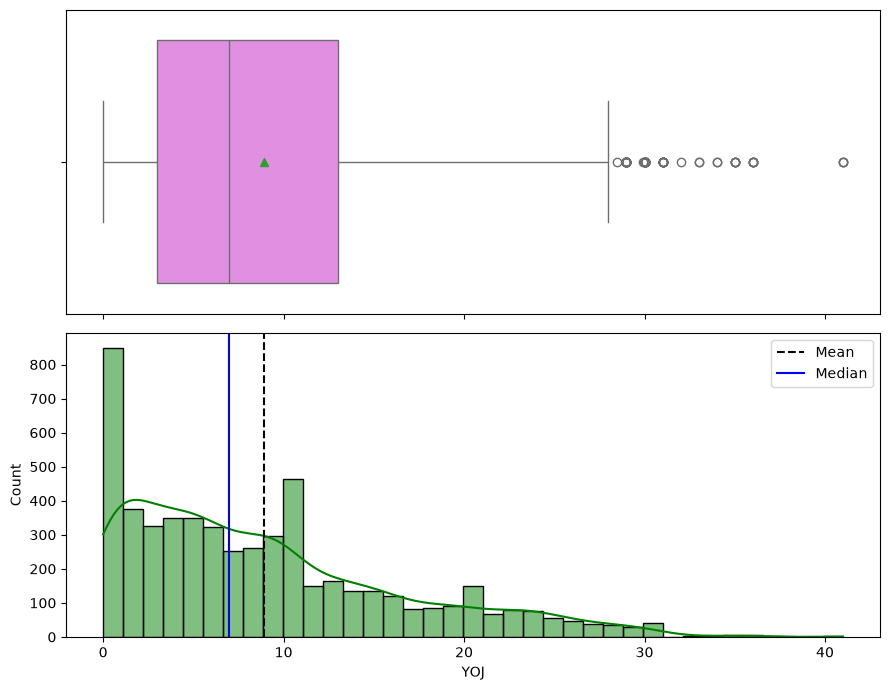

In [255]:
hist_boxplot(df, 'YOJ')

The YOJ distribution is right-skewed, with the majority of borrowers having been at their current job for fewer than 10 years. The median (7 years) is lower than the mean (9 years), reflecting the influence of a number of applicants with 30+ years of job tenure. These high values are realistic — long-tenured employees do exist and do not require outlier treatment. Job stability is generally considered a positive creditworthiness indicator.

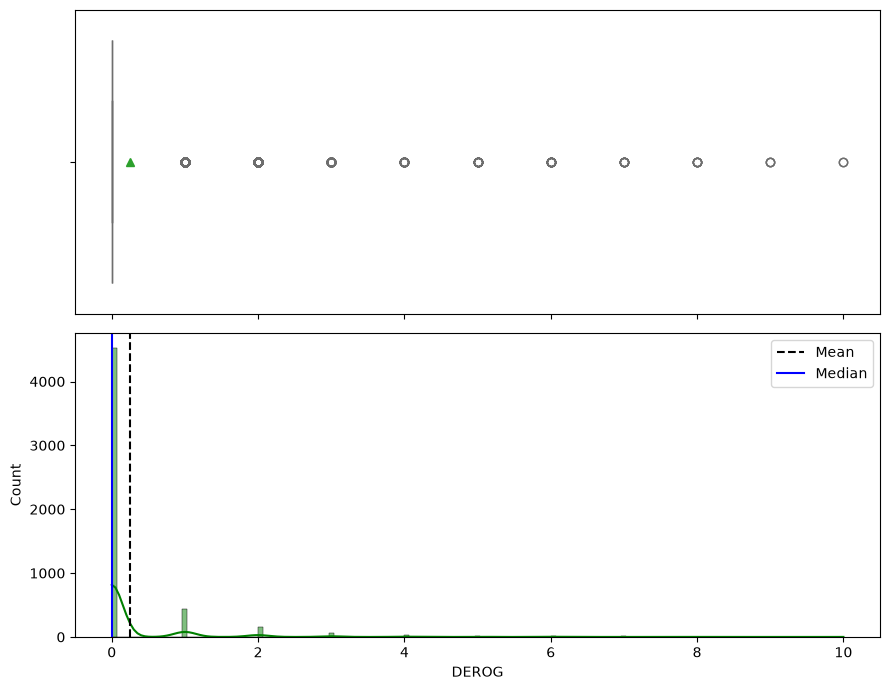

In [256]:
hist_boxplot(df, 'DEROG')

he DEROG distribution shows highly concentrated data at zero, indicating that the majority of borrowers are in good standing with no major derogatory marks on their credit history. Applicants with 1 or 2 derogatory marks already appear as outliers, while those with 3 or more represent very high-risk borrowers whose applications should be monitored closely to mitigate default risk. Values reaching 8–10 derogatory marks raise an important question: whether these marks appeared before or after loan approval, as approving borrowers with such severe credit history could indicate flawed underwriting decisions, which is precisely the bias this model aims to detect and correct.

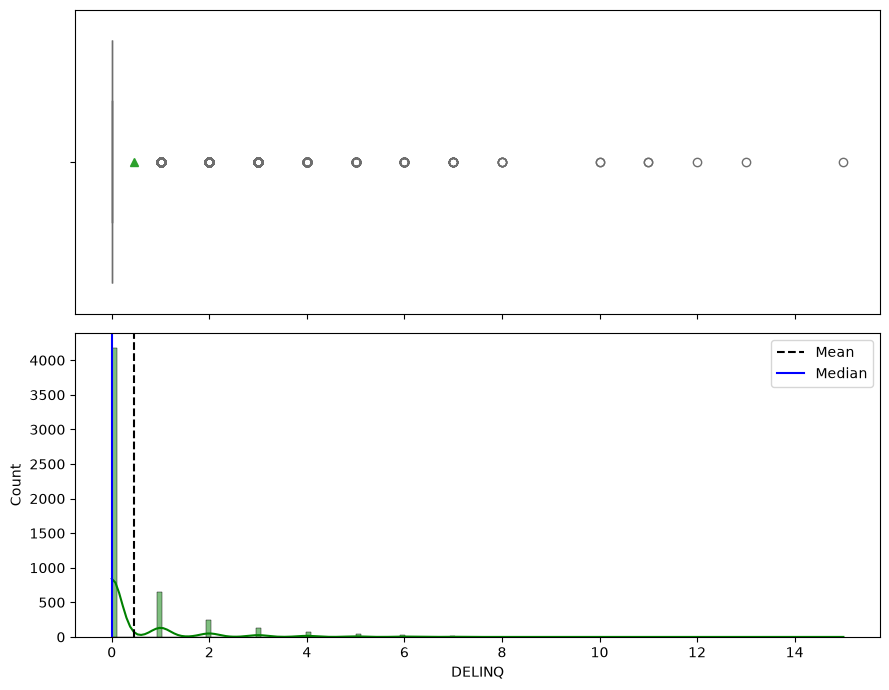

In [257]:
hist_boxplot(df, 'DELINQ')

The DELINQ distribution is similarly concentrated at zero, with the vast majority of borrowers having no delinquent credit lines, a positive indicator suggesting that loans were generally underwritten correctly and borrowers are able to meet their monthly payment obligations. Applicants with 2 or more delinquent credit lines appear as outliers, with values extending up to 15, which is a strong red flag for default risk. These extreme values will be important predictors in our classification models.

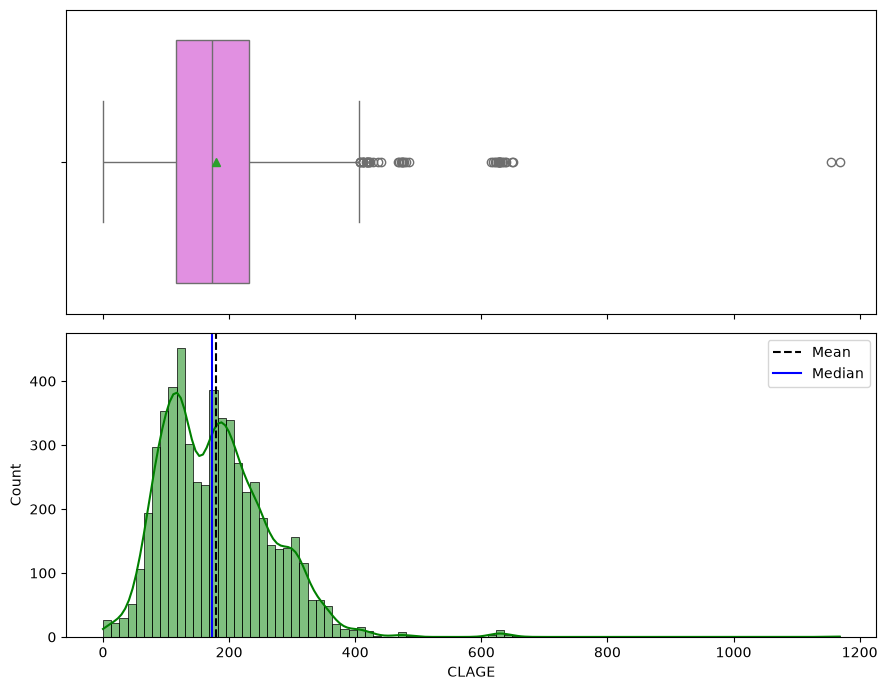

In [258]:
hist_boxplot(df, 'CLAGE')

The CLAGE distribution shows that the mean and median are close to each other at approximately 180 and 173 months respectively (14–15 years), indicating that most borrowers have established credit histories ranging between 8–25 years. Values above 600 months (50 years) are rare but plausible for very old accounts. However, the extreme outlier at 1,170 months (approximately 97 years) is almost certainly a data entry error, as it would predate most modern credit systems. These extreme values should be treated during preprocessing to avoid introducing bias into the model.

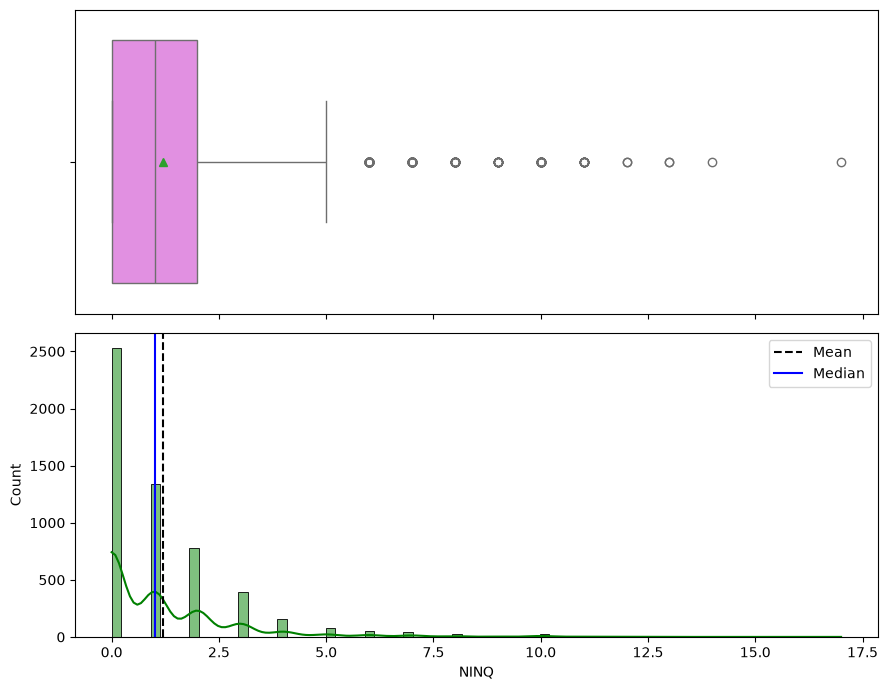

In [259]:
hist_boxplot(df, 'NINQ')

The NINQ distribution is heavily right-skewed, with most borrowers having 0–1 recent credit inquiries, which is a low-risk indicator. The median (1) and mean (1.20) are very close, confirming that the bulk of the data is concentrated at the low end. However, values above 5 inquiries are concerning, as multiple recent credit inquiries can indicate financial distress or aggressive credit-seeking behavior — both red flags for default risk. The extreme outlier at 17 inquiries warrants light outlier treatment during preprocessing.

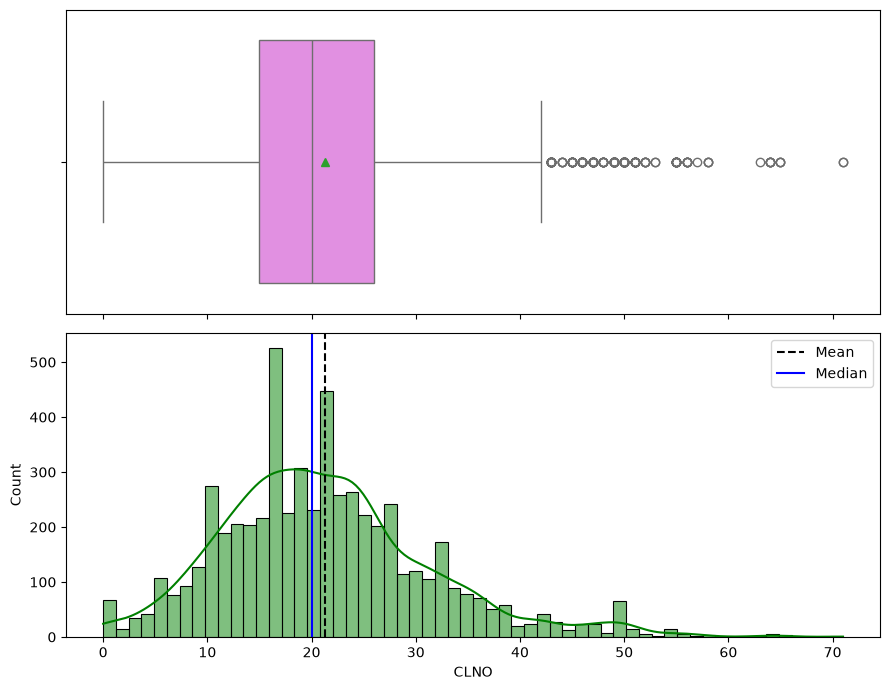

In [260]:
hist_boxplot(df, 'CLNO')

The CLNO distribution is the most normally distributed variable we have seen so far, with the mean (21) and median (20) closely aligned and the data centered around 15–25 credit lines. This suggests most borrowers have a well-established and diverse credit portfolio. There are some outliers above 50 credit lines, with a maximum of 71, which may reflect borrowers with extensive credit histories. These outliers are relatively few and do not significantly skew the distribution, so no aggressive treatment is required and could be left as it is.

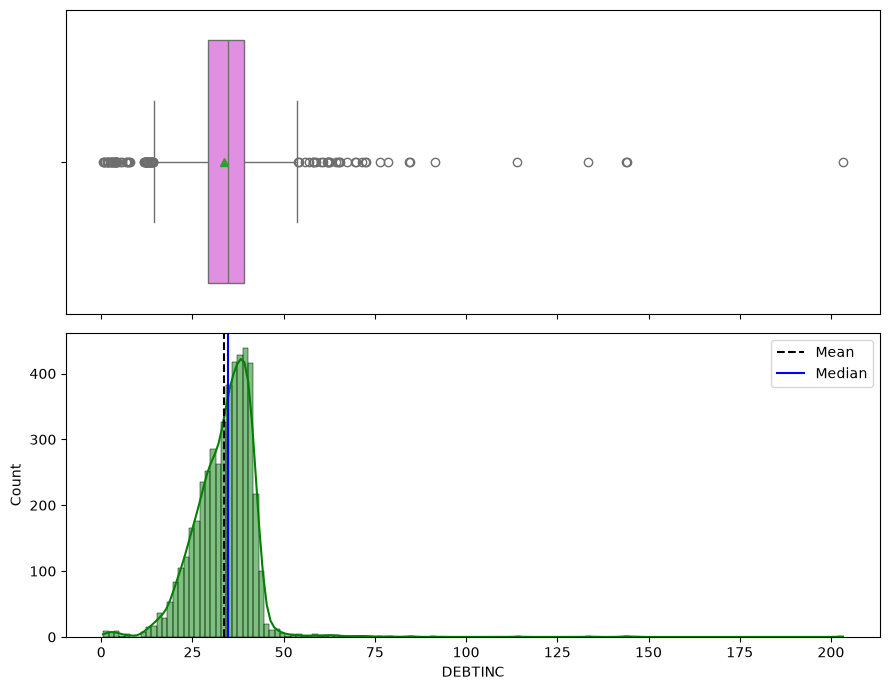

In [261]:
hist_boxplot(df, 'DEBTINC')

The DEBTINC (debt-to-income ratio) distribution is highly right-skewed, with the majority of borrowers concentrated in the 25–50% range, which is considered a normal and healthy DTI level in lending. The mean (33%) and median (35%) are closely aligned, confirming that the core data is well-centered. However, there are extreme outliers on both ends: values near 0% on the left side may indicate missing or incorrectly recorded data, while the maximum value of 203% is almost certainly a data error, as it is financially impossible for a borrower's monthly debt payments to exceed twice their gross monthly income. Given that DEBTINC already has the highest missing value rate (21.26%), these extreme outliers should be treated during preprocessing, as they could significantly bias the model's predictions.

In [262]:
# Creting a function to process the univariate analysis of each categorical column
def perc_bar_plot(data, feature, figsize=(9,7)):
    fig, ax = plt.subplots(figsize=figsize)
    total=len(data[feature])
    sns.countplot(data=data, x=feature, ax=ax,hue=feature, palette='viridis',
        order=data[feature].value_counts().index)
    
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x=p.get_x() + p.get_width() / 2-0.05
        y=p.get_height()

        ax.annotate(percentage, (x,y), size=10, ha='center')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close('all')

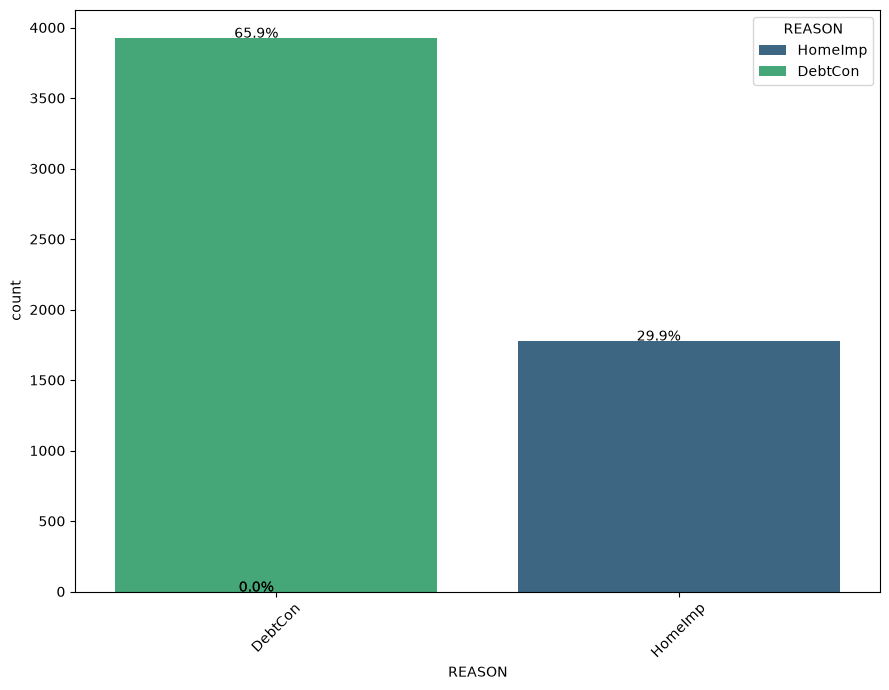

In [263]:
perc_bar_plot(df, 'REASON')

The REASON distribution shows that the majority of borrowers (65.9%) applied for debt consolidation loans, while 29.9% applied for home improvement purposes. The remaining 4.2% represent missing values that will need to be addressed during preprocessing. Both loan purposes are legitimate and commonly seen in home equity lending, and no unusual patterns are present in this variable.

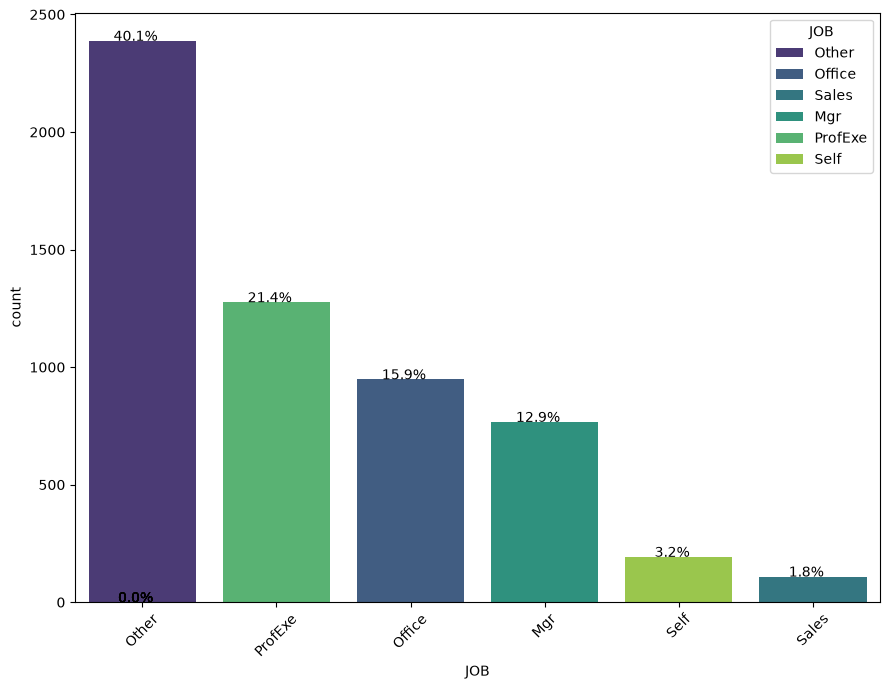

In [264]:
perc_bar_plot(df, 'JOB')

The JOB distribution shows that 'Other' is the dominant category at 40.1%, which is concerning as it provides no meaningful information about the borrower's employment type. The remaining categories — Professional Executive (21.4%), Office (15.9%), and Manager (12.9%) — suggest that the majority of identifiable borrowers hold white-collar positions. Self-employed borrowers account for only 3.2% and Sales for 1.8%; however, given the large 'Other' category, it is reasonable to assume that some self-employed borrowers may have been grouped there. The 4.7% missing values in JOB further reduce the quality of this feature. This variable should be interpreted with caution during model analysis, as the broad 'Other' category may introduce noise into the predictions.

### Bivariate Analysis ###

Having examined each variable individually, we will now explore the relationships between pairs of variables. Bivariate analysis helps us understand how each feature interacts with the target variable BAD, allowing us to identify which factors are most strongly associated with loan default.

In [265]:
# Function for bivariate analysis, numerical vs target variable

def bivariate_boxplot(data, feature, target='BAD', figsize=(9,7)):
    fix, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=data, x=target, y=feature, palette='viridis', ax=ax,
        showmeans=True)
    plt.title(f'{feature} by Default Status')
    plt.xlabel('Default (0 = No, 1 = Yes)')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

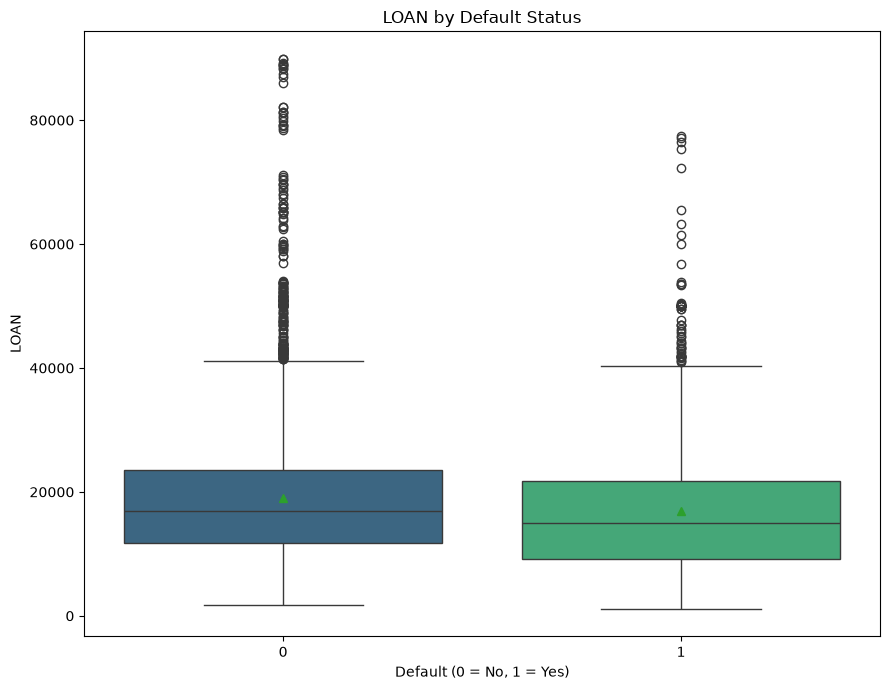

In [266]:
bivariate_boxplot(df, 'LOAN')

The boxplot shows that defaulters tend to have slightly lower loan amounts compared to non-defaulters, suggesting that loan amount alone is not a strong predictor of default. The means of both groups are relatively close to each other, indicating that borrowers across all loan sizes are at risk of defaulting. This confirms that other factors such as delinquency history, debt-to-income ratio, and derogatory marks are likely to play a more significant role in predicting default.

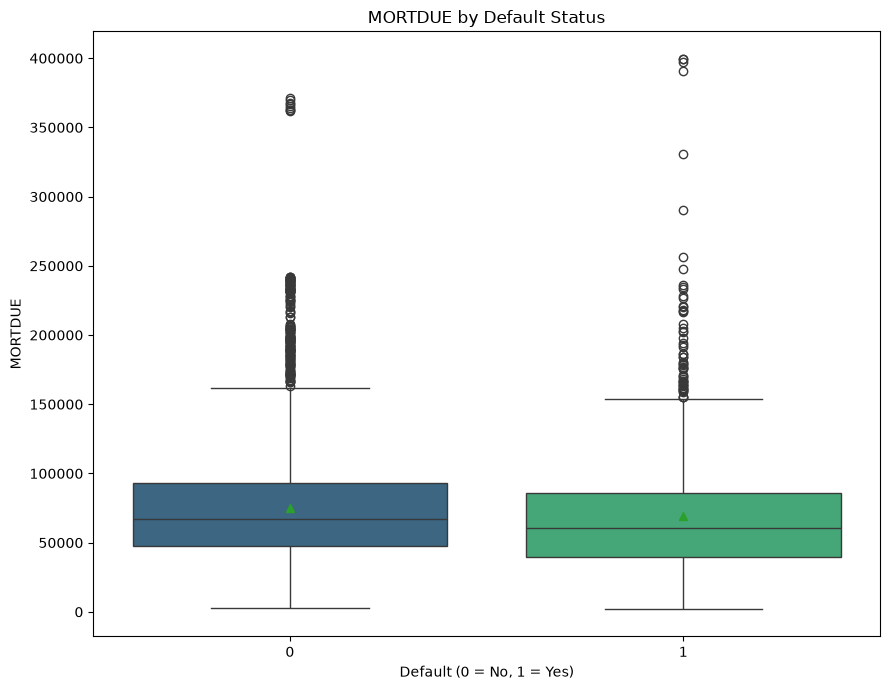

In [267]:
bivariate_boxplot(df, 'MORTDUE')

The MORTDUE distributions for defaulters and non-defaulters are nearly identical in terms of distribution. Existing mortgage balance shows no meaningful difference between the two groups, making it a weak standalone predictor of default. Its predictive value may only emerge when combined with other financial variables such as property value and debt-to-income ratio.

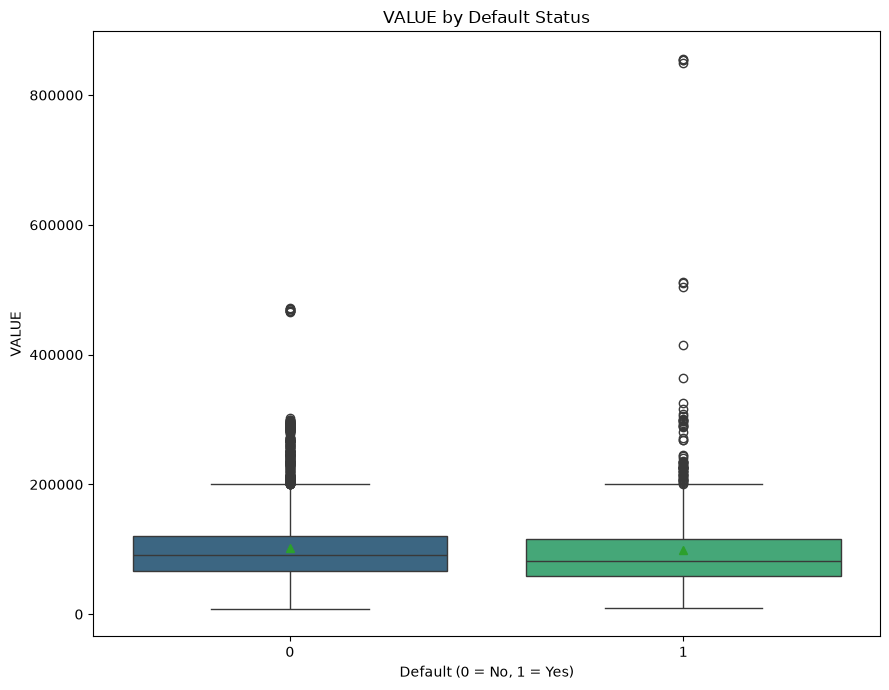

In [268]:
bivariate_boxplot(df, 'VALUE')

As per the graph, the VALUE distribution is largely similar for default and non-default accounts. However, defaulters show notably more high-value property outliers, which is an interesting finding, it suggests that even borrowers with high-value properties are not immune to default, possibly due to over-leveraging or poor cash flow management. Property value alone is not a strong standalone predictor of default, but may contribute meaningfully when combined with loan amount and mortgage due as a loan-to-value ratio.

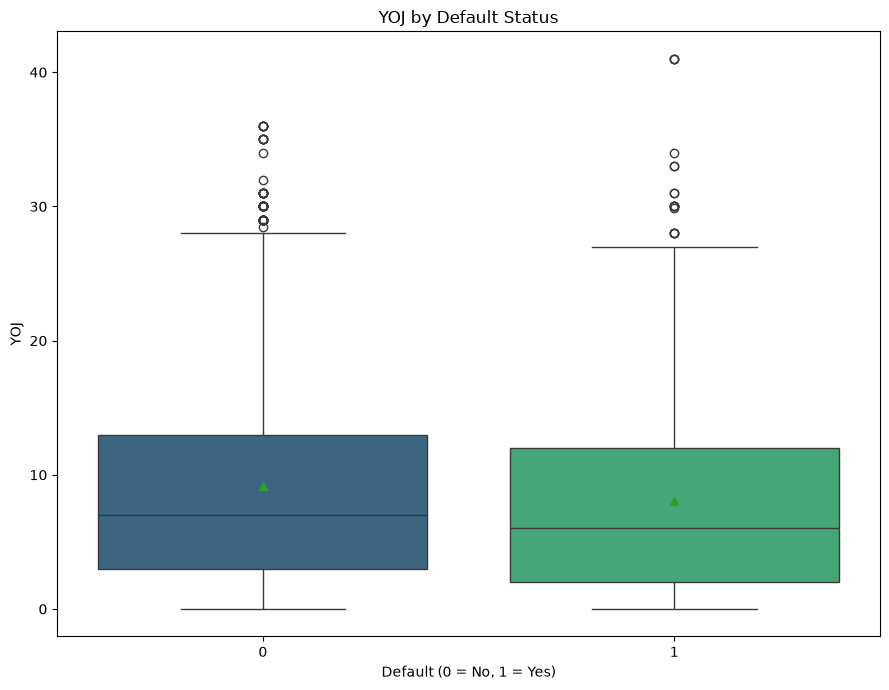

In [269]:
bivariate_boxplot(df, 'YOJ')

As per YOJ boxplot, the mean years at current job is slightly higher for non-defaulters (approximately 9 years) compared to defaulters (approximately 8 years). However, the difference is minimal and the overlap between the two groups is significant, indicating that job tenure alone is not a strong standalone predictor of default. Borrowers with fewer years of job tenure appear slightly more likely to default, which aligns with the general lending principle that employment stability is a positive creditworthiness indicator.

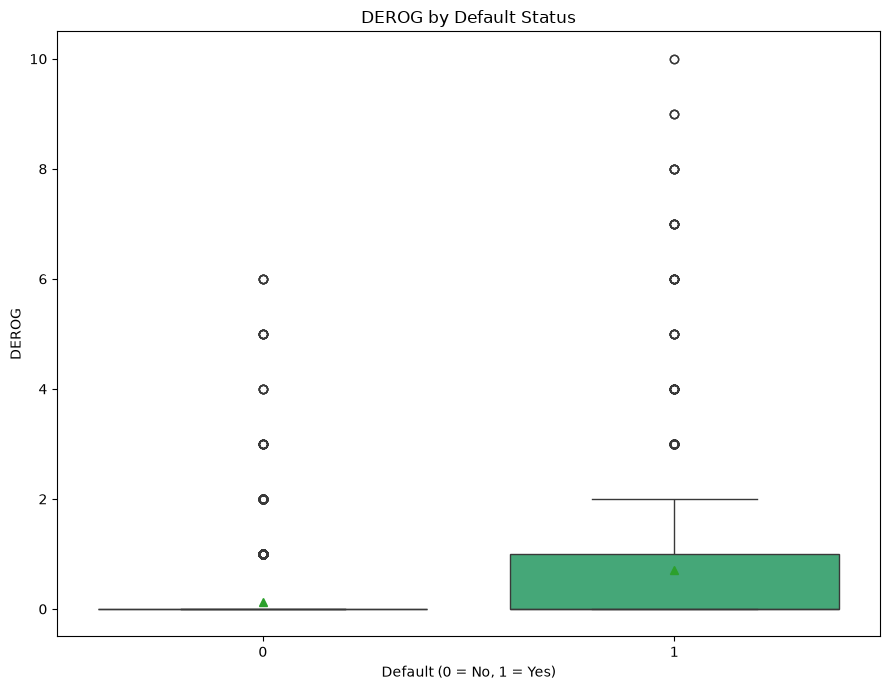

In [270]:
bivariate_boxplot(df, 'DEROG')

The DEROG boxplot reveals one of the most striking differences seen so far between defaulters and non-defaulters. Non-defaulters are almost entirely concentrated at zero derogatory marks, with a mean near zero, while defaulters show a clearly elevated distribution with a visible interquartile range between 0 and 2 and a mean above zero. This strongly suggests that derogatory marks are a significant predictor of loan default — borrowers with even one major derogatory report carry a substantially higher risk of default. This variable is expected to be among the most important features in our classification models.

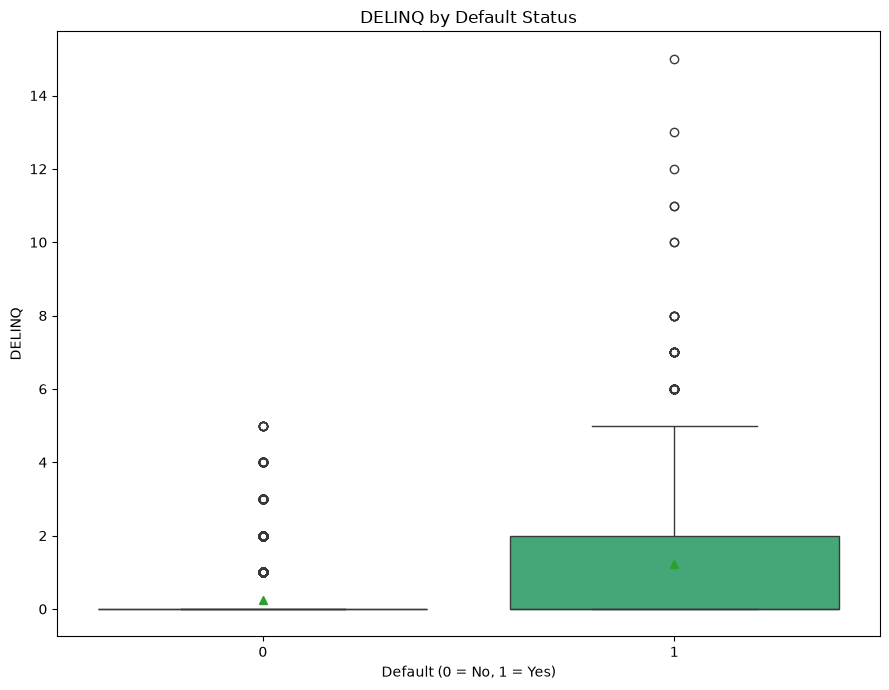

In [271]:
bivariate_boxplot(df, 'DELINQ')

Similar to DEROG, the DELINQ boxplot shows a clear and meaningful separation between defaulters and non-defaulters. Non-defaulters are overwhelmingly concentrated at zero delinquent credit lines, while defaulters exhibit a visible interquartile range between 0 and 2, with a mean above 1 and extreme outliers reaching up to 15. This confirms that delinquency in debt payments is a strong predictor of loan default. From a lending operations perspective, raising an automated flag when a borrower's delinquency count increases would be a valuable risk mitigation strategy, and this variable is expected to be among the top predictors in our classification models.

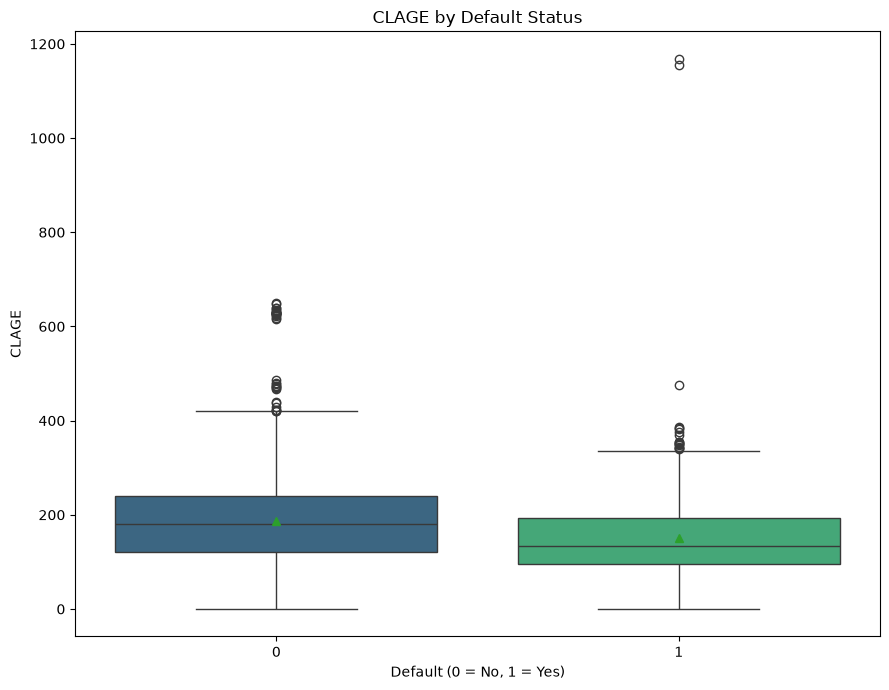

In [272]:
bivariate_boxplot(df, 'CLAGE')

The credit line age boxplot shows a modest but visible difference between the two groups: non-defaulters tend to have older credit lines, with a mean of approximately 190 months (roughly 16 years), compared to defaulters whose mean is closer to 150 months (approximately 12.5 years). This suggests that borrowers with longer credit histories are slightly less likely to default, which aligns with the lending principle that an established credit history indicates greater financial responsibility. While not the strongest predictor, CLAGE may contribute meaningfully to the model alongside other credit behavior variables.

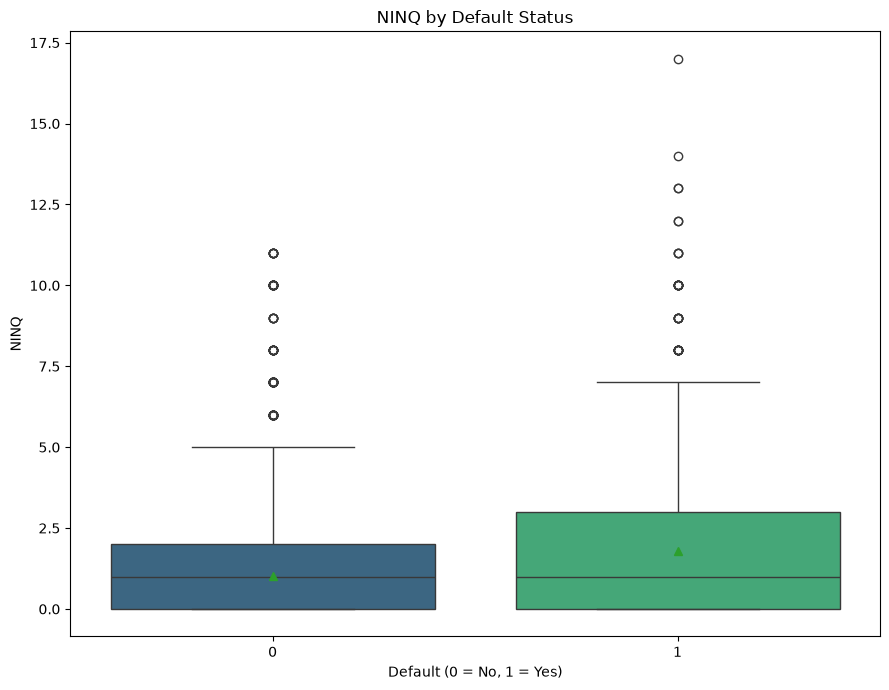

In [273]:
bivariate_boxplot(df, 'NINQ')

The number of recent credit inquiries feature shows that defaulters tend to have a higher number of credit inquiries compared to non-defaulters, with more extreme outliers reaching up to 17. This supports the principle that multiple recent credit inquiries can be a red flag, as they may indicate a borrower is actively seeking credit from multiple sources due to financial distress. While the means of both groups are relatively close, the greater spread among defaulters suggests that NINQ has moderate predictive value for default risk.

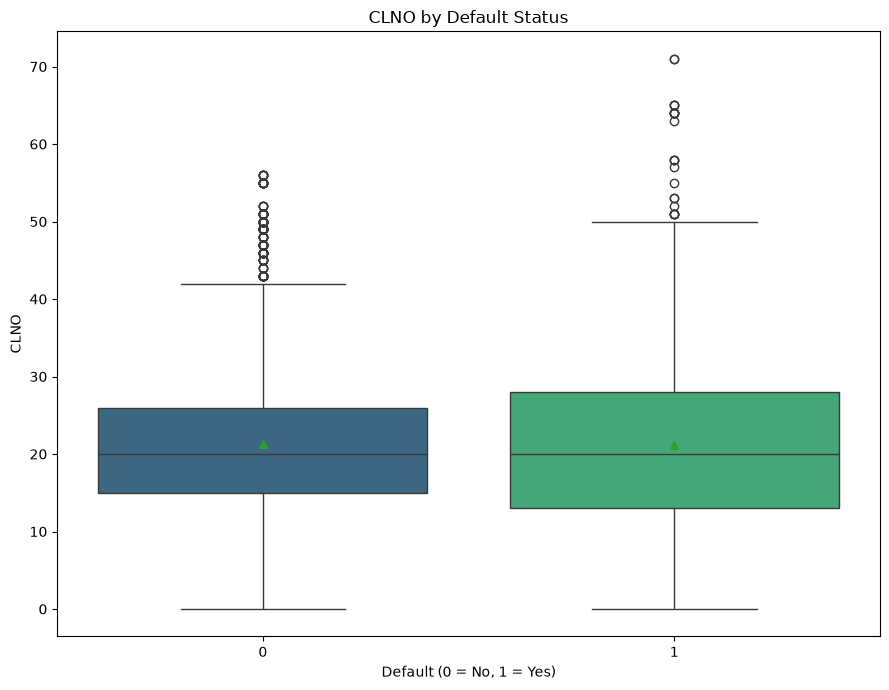

In [274]:
bivariate_boxplot(df, 'CLNO')

Both groups share nearly identical means around 20 credit lines, and the medians are virtually indistinguishable. The number of existing credit lines appears to carry little weight in separating borrowers who repay from those who don't. Interestingly, defaulters show a slightly wider spread in their distribution, hinting that having too few or too many open credit lines may marginally elevate risk, though this effect is weak at best.

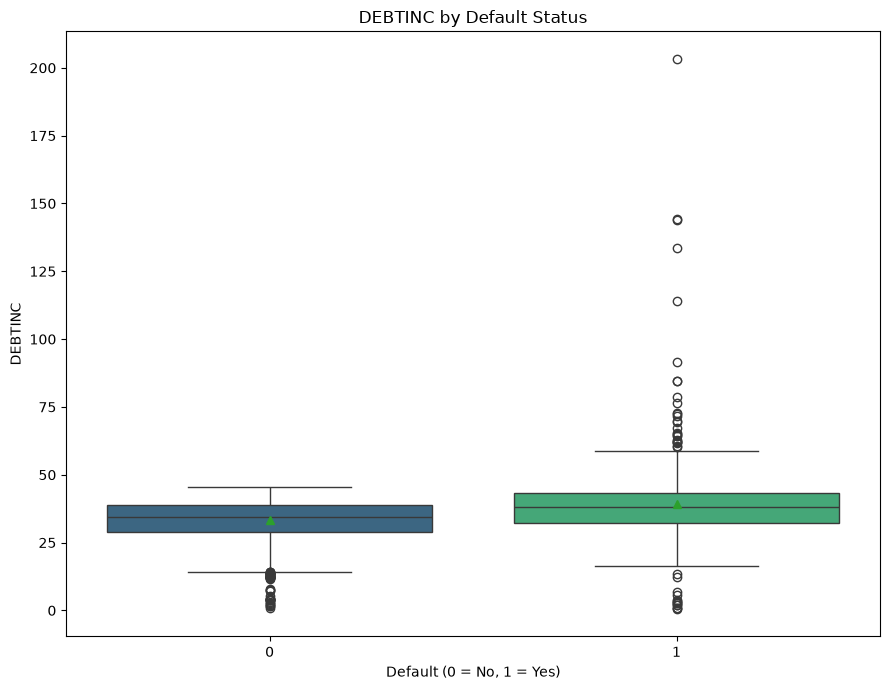

In [275]:
bivariate_boxplot(df, 'DEBTINC')

The DEBTINC graph reveals a clear picture — defaulters carry a noticeably higher debt-to-income ratio, with both a higher mean and a much wider spread compared to borrowers who repaid. The extreme outliers exclusively appearing in the defaulter group, reaching up to 203%, reinforce that excessive debt burden relative to income is a powerful warning sign. Given this separation between the two groups, debt-to-income is expected to rank among the top predictors in the model — making its 21% missing value rate a critical preprocessing challenge that must be handled carefully to avoid losing the important feature information.

In [276]:
# Function for bivariate analysis - categorical vs target variable
def stacked_bar_plot(data,feature, target='BAD', figsize=(9,7)):
    tab = pd.crosstab(data[feature], data[target], normalize='index')
    tab.plot(kind='bar', stacked=True, figsize=figsize, colormap='Set2',
        edgecolor='none')
    plt.title(f'Default Rate by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Proportion')
    plt.legend(['No Default', 'Default'], loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


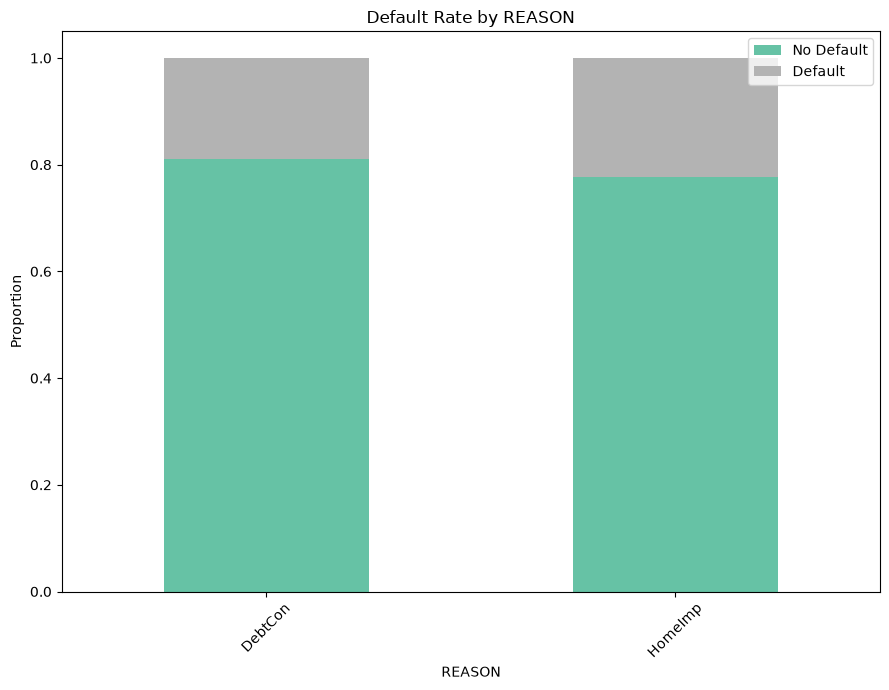

In [277]:
stacked_bar_plot(df, 'REASON')

The default rates for both loan purposes are remarkably similar. Approximately 19% for debt consolidation and 21% for home improvement indicating that the reason for the loan request has minimal impact on default likelihood. However, the slightly lower default rate among debt consolidation borrowers is an interesting nuance, as consolidating existing debt may help reduce overall financial pressure and improve a borrower's ability to meet payment obligations. REASON alone is unlikely to be a strong feature in the model, but may contribute marginally when combined with other variables.

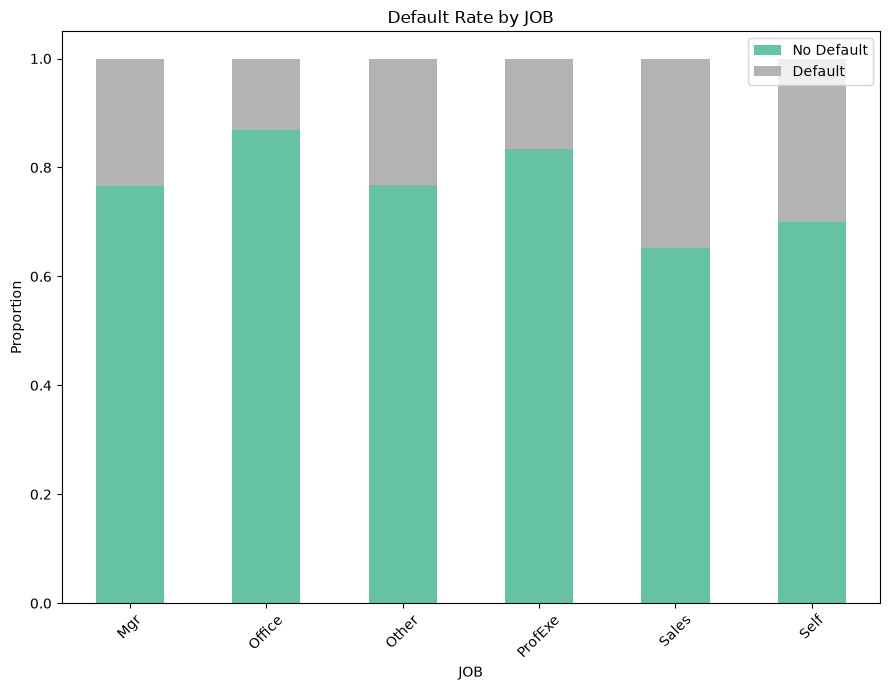

In [278]:
stacked_bar_plot(df, 'JOB')

The JOB category reveals meaningful differences in default rates across employment types. Office workers exhibit the lowest default rate at approximately 14%, likely due to the stability of fixed or hourly salaries that allow for predictable budgeting and expense planning. Professional Executives follow closely at around 17%, reflecting their generally higher and more stable income levels. At the other end, Sales workers carry the highest default rate at approximately 35%, which aligns with the variable and commission-based nature of sales income — while sales roles can yield high earnings, the inconsistency of that income makes it harder to meet fixed monthly debt obligations. Self-employed borrowers also show elevated default risk at around 30%, as irregular income streams make financial planning more challenging. This variable shows meaningful separation across categories and is expected to contribute to the model's predictive power.

### Multivariate Analysis ###

Having explored individual variables and their relationships with the target, we will now examine how all numerical variables interact with each other simultaneously. The correlation heatmap allows us to identify multicollinearity between features, which is important for model building, as highly correlated features may introduce redundancy and reduce model interpretability. Additionally, the pairplot will provide a visual overview of pairwise relationships across all numerical variables, colored by default status, helping us identify patterns that may not be visible in individual charts.

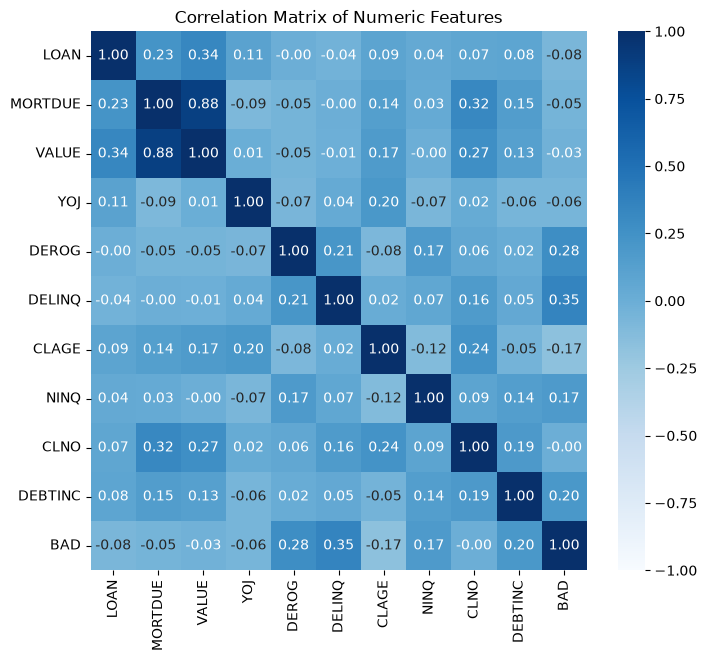

In [279]:
# Creating a correlation plot
plt.figure(figsize=(8,7))

sns.heatmap(data=df[numerical_cols + ['BAD']].corr(), annot=True, vmin=-1, vmax=1,
    center=0, fmt='.2f', cmap='Blues')

plt.title('Correlation Matrix of Numeric Features')
plt.show()

The correlation matrix reveals several notable relationships among the numerical features. The strongest correlation in the dataset is between MORTDUE and VALUE (0.88), which is expected. Properties with higher market values naturally carry larger outstanding mortgage balances. 

LOAN and VALUE show a moderate correlation (0.34), reflecting that borrowers with more valuable properties tend to request larger equity lines, though the relationship is not as strong since home equity loans are primarily used for improvement or debt consolidation rather than property acquisition.

DEROG and DELINQ show a meaningful positive correlation (0.21), which makes intuitive sense, borrowers with major derogatory marks on their credit history are also more likely to have delinquent credit lines, as both reflect patterns of poor repayment behavior.

CLAGE and CLNO are moderately correlated (0.24), suggesting that borrowers with longer credit histories tend to accumulate more credit lines over time. 

CLNO and MORTDUE also show a moderate relationship (0.32), indicating that borrowers with more credit lines tend to carry higher mortgage balances.

Importantly, most features show weak correlations with each other, which is favorable for model building as it reduces multicollinearity concerns. No single pair of features outside of MORTDUE and VALUE is correlated strongly enough to warrant removal.

The matrix shows very few meaningful negative correlations. The most notable is between CLAGE and NINQ (-0.12), suggesting that borrowers with longer established credit histories tend to make fewer recent credit inquiries, likely because they have less need to seek new credit. 

DEROG and CLAGE also show a slight negative relationship (-0.08), indicating that more established borrowers tend to have cleaner credit records. However, none of the negative correlations are strong enough to be considered significant, reinforcing that the features in this dataset are largely independent of one another.

Looking at the BAD target variable specifically, DELINQ (0.35) and DEROG (0.28) show the strongest positive correlations with default, confirming what we observed in the bivariate analysis — poor payment history is the most reliable signal of default risk. 

DEBTINC (0.20) and NINQ (0.17) follow, reinforcing that high debt burden and aggressive credit seeking are meaningful risk indicators. 

On the negative side, CLAGE (-0.17) has the strongest inverse relationship with default, suggesting that borrowers with longer established credit histories are less likely to default. Loan amount, property value, and mortgage balance show near-zero correlation with BAD, confirming they carry minimal standalone predictive power.

<Figure size 700x800 with 0 Axes>

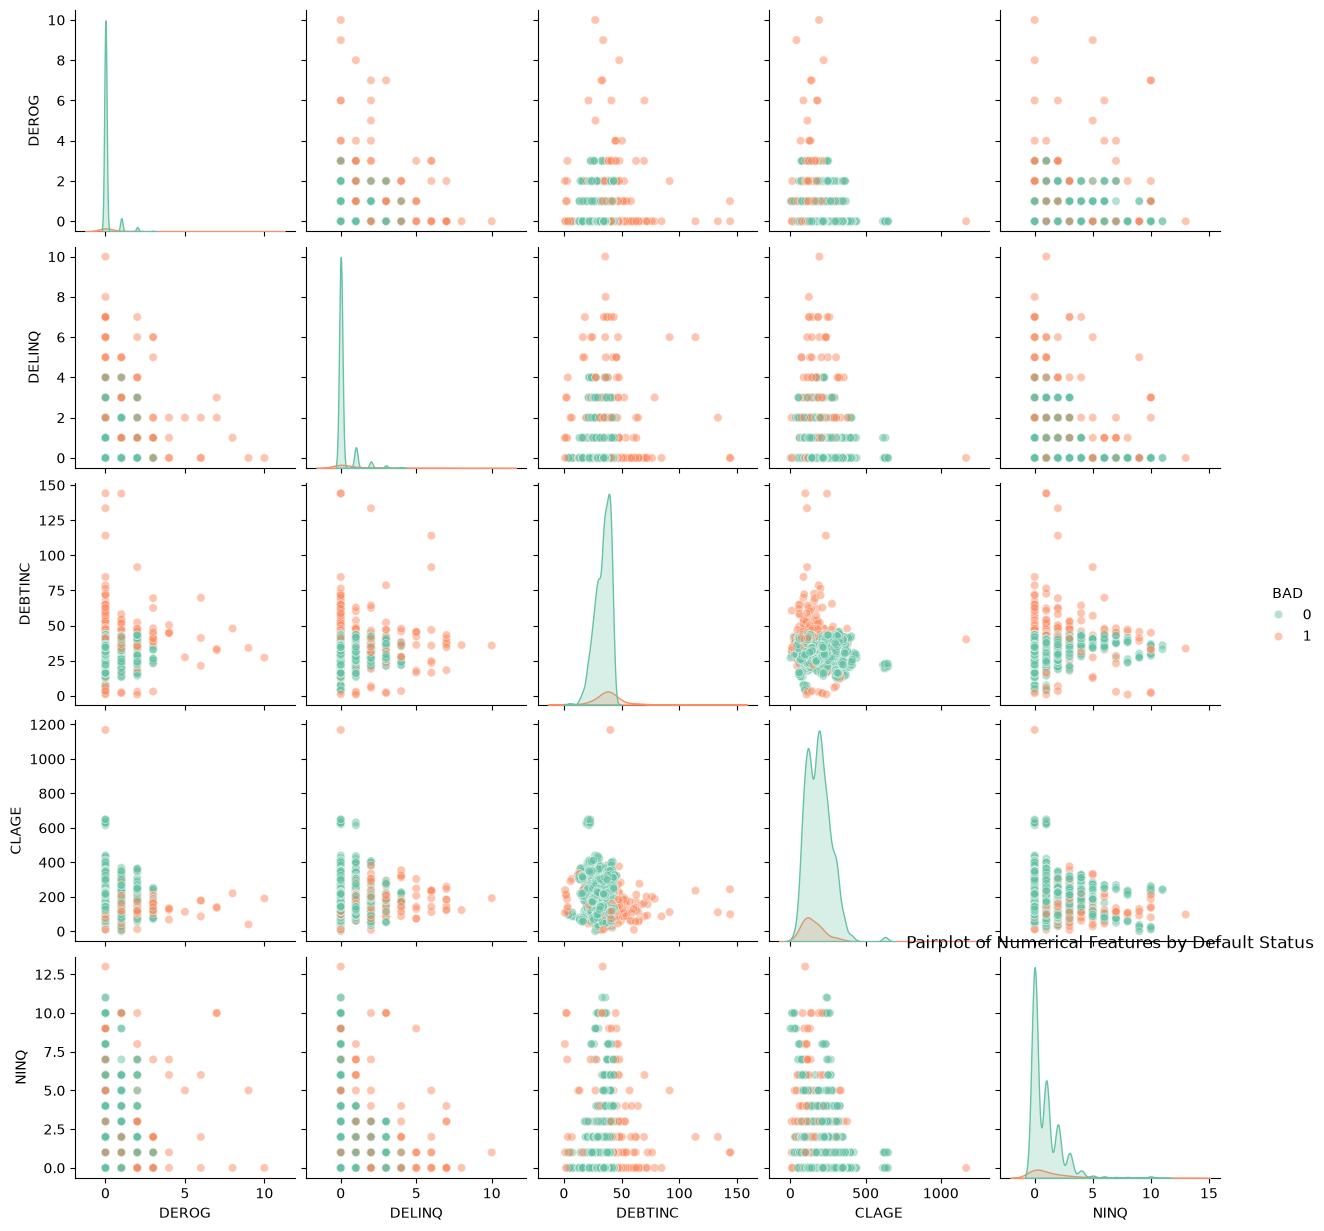

In [280]:
# Pairplot of most important features only
plt.figure(figsize=(7,8))

key_cols = ['DEROG', 'DELINQ', 'DEBTINC', 'CLAGE', 'NINQ', 'BAD']

sns.pairplot(df[key_cols].dropna(), hue='BAD', palette='Set2',
    plot_kws={'alpha': 0.5}, diag_kind='kde')

plt.title('Pairplot of Numerical Features by Default Status')
plt.show()

The diagonal KDE curves for DEROG and DELINQ show a sharp separation: non-defaulters (green) are heavily concentrated at zero, while defaulters (orange) spread toward higher values, visually confirming their strong predictive power. 

The DEBTINC diagonal shows that defaulters have a flatter, wider distribution compared to the tight green cluster of non-defaulters, reinforcing that higher debt burden correlates with default risk. The CLAGE diagonal reveals that non-defaulters tend to have longer established credit histories, while defaulters skew toward shorter credit ages. 

In the scatterplots, the DEROG vs DELINQ pair shows that orange dots dominate the upper right quadrant. Borrowers with both high derogatory marks and high delinquency counts are almost exclusively defaulters. 

Overall this pairplot provides strong visual confirmation that credit behavior variables are far more informative than financial size variables for predicting default.

#### EDA Summary ####

Based on the exploratory data analysis, several key findings emerged. DELINQ and DEROG are the strongest predictors of loan default, with defaulters showing significantly higher values in both variables compared to non-defaulters. 

DEBTINC is the third most important predictor, with defaulters carrying notably higher debt-to-income ratios, however its 21% missing value rate makes careful imputation critical. 

CLAGE shows a meaningful negative relationship with default: borrowers with longer credit histories are less likely to default. 

Financial size variables such as LOAN, MORTDUE, and VALUE show minimal separation between the two groups and are expected to contribute little predictive power individually. The dataset contains a class imbalance of approximately 80/20 between non-defaulters and defaulters, which must be addressed during model building to avoid biased predictions. 

Missing values are present across multiple columns and outliers have been identified in several variables, both will be treated in the preprocessing stage before model training begins.

### Data Preprocessing ###

#### Outlier Treatment ####

Before applying outlier treatment, it is important to note that not all numerical columns should be treated using the standard IQR method. DEROG and DELINQ are excluded from this process, as their 75th percentile sits at 0, meaning the vast majority of borrowers have no derogatory marks or delinquent credit lines. Applying IQR capping to these columns would incorrectly flag legitimate non-zero values as outliers and compress the very signal that makes these variables strong predictors of default, as confirmed during bivariate analysis. IQR capping will therefore be applied only to LOAN, MORTDUE, VALUE, YOJ, CLAGE, NINQ, CLNO, and DEBTINC, where extreme values are more likely to represent genuine outliers rather than meaningful risk indicators.

In [281]:
# Function to treat outliers using IQR capping

def outlier_treatment(data,col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    IQR = q3-q1
    lower_wisker = q1 - 1.5 * IQR
    upper_wisker = q3 + 1.5 * IQR
    data[col] = np.clip(data[col], lower_wisker, upper_wisker)
    return data

In [282]:
#  Applies outlier treatment to a specific list of numerical columns

cols_to_treat = ['LOAN', 'MORTDUE', 'VALUE', 
    'YOJ', 'CLAGE', 'NINQ', 'DEBTINC', 'CLNO']

for col in cols_to_treat:
    df = outlier_treatment(df, col)

df.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18051.895973,71566.093752,98538.057633,8.873159,0.254570,0.449442,178.635811,1.093394,21.032851,33.681973
std,0.399656,9252.565294,37203.654400,45070.800236,7.430914,0.846047,1.127266,80.495471,1.372692,9.420239,7.135236
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.345367
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,41600.000000,159306.000000,200447.375000,28.000000,10.000000,15.000000,406.230642,5.000000,42.500000,53.797805


#### Missing Value Treatment ####

Missing values will be imputed differently based on data type. Numerical columns will be filled using the median, as it is robust to skewed distributions and outliers. Categorical columns (REASON and JOB) will be filled using the mode, replacing missing entries with the most frequently occurring category.

### KNN Imputation ###

DEBTINC will be imputed separately using K-Nearest Neighbors (KNN) Imputation rather than median imputation. This decision is based on two factors: DEBTINC has the highest missing value rate in the dataset (21.26%), and it is one of the strongest predictors of loan default identified during EDA. 

Given its importance, a more sophisticated imputation method is justified to preserve the signal in this variable as accurately as possible. KNN Imputation will estimate each missing DEBTINC value by finding the 5 most similar borrowers based on their LOAN, MORTDUE, and VALUE — financial variables that are logically related to a borrower's debt-to-income ratio — and using their average DEBTINC value as the estimate. This approach produces more contextually accurate imputations than a single fixed median value, since it accounts for each borrower's individual financial profile rather than applying the same value to every missing entry.

In [283]:
# Impute DEBTINC column with KNN 
from sklearn.impute import KNNImputer

knn_features=['LOAN', 'MORTDUE', 'VALUE', 'DEBTINC']
knn_imputer = KNNImputer(n_neighbors=5)
df[knn_features] = knn_imputer.fit_transform(df[knn_features])

df['DEBTINC'].isnull().sum()

np.int64(0)

In [284]:
# Median imputation for remaining numerical columns

missing_value_num_cols = [col for col in numerical_cols
    if col !='DEBTINC']

for col in missing_value_num_cols:
    df[col] = df[col].fillna(df[col].median())

df[missing_value_num_cols].isnull().sum()


LOAN       0
MORTDUE    0
VALUE      0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
dtype: int64

In [285]:
# Mode imputation for categorical columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df[categorical_cols].isnull().sum()

REASON    0
JOB       0
dtype: int64

In [286]:
# Export analysis-ready data for Power BI (pre-encoding/scaling)
df_powerbi = df.copy()
df_powerbi.insert(0, 'Record_ID', df_powerbi.index)
df_powerbi.to_csv('hmeq_clean.csv', index=False)


#### Encoding Categorical Columns ####

In [287]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in categorical_cols:
    df[col]=le.fit_transform(df[col])

for col in categorical_cols:
    print(f"{col} mapping:")
    le.fit(data[col].dropna())
    for i, category in enumerate(le.classes_):
        print(f"  {category} → {i}")
    print()

df[categorical_cols].head()

REASON mapping:
  DebtCon → 0
  HomeImp → 1

JOB mapping:
  Mgr → 0
  Office → 1
  Other → 2
  ProfExe → 3
  Sales → 4
  Self → 5



,REASON,JOB
0,1,2
1,1,2
2,1,2
3,0,2
4,1,1


By encoding the REASON column, we successfully converted it into two numerical categories - DebtCon (0) and HomeImp (1) — while JOB was encoded into six categories ranging from Mgr (0) to Self (5), following alphabetical order. Reviewing the first five rows of the encoded dataset, REASON values of 1 and 0 correctly correspond to HomeImp and DebtCon respectively, and JOB values of 1 and 2 correspond to Office and Other, consistent with the original dataset structure. Both categorical variables are now fully numerical and ready to be used in model training. As noted, the assigned integers do not carry inherent ranking meaning, which is acceptable for tree-based models but should be interpreted with caution if used in linear models like Logistic Regression

#### Standard Scaling ####

## Feature Scaling

Numerical features were scaled using StandardScaler, which transformed each variable to have a mean of 0 and a standard deviation of 1. This step is primarily important for Logistic Regression that will be used as a base model for a loan default prediction, as it is sensitive to differences in feature magnitude. 

In [288]:
# Applying StandardScaler to Columns

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df[numerical_cols].describe()


,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5.960000e+03,5.960000e+03,5.960000e+03,5.960000e+03,5.960000e+03,5.960000e+03,5.960000e+03,5.960000e+03,5.960000e+03,5.960000e+03
mean,7.629989e-17,1.907497e-16,3.814995e-17,-1.001436e-16,1.371014e-17,5.960929e-17,2.861246e-16,5.245618e-17,-1.049124e-16,3.051996e-16
std,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00
min,-1.832283e+00,-1.896725e+00,-2.003021e+00,-1.223251e+00,-2.809762e-01,-3.759430e-01,-2.275419e+00,-8.267924e-01,-2.271039e+00,-2.768848e+00
25%,-7.514110e-01,-6.773590e-01,-7.172352e-01,-8.019875e-01,-2.809762e-01,-3.759430e-01,-7.781315e-01,-8.267924e-01,-6.484340e-01,-6.816184e-01
50%,-1.893575e-01,-1.693249e-01,-2.082924e-01,-2.403028e-01,-2.809762e-01,-3.759430e-01,-6.253415e-02,-6.505446e-02,-1.075656e-01,1.101381e-01
75%,5.672529e-01,5.314017e-01,4.683653e-01,4.618031e-01,-2.809762e-01,-3.759430e-01,6.222064e-01,6.966834e-01,5.414764e-01,7.663466e-01
max,2.545249e+00,2.445088e+00,2.280072e+00,2.708542e+00,1.224421e+01,1.352369e+01,2.906796e+00,2.981897e+00,2.326342e+00,3.038530e+00


By using StandardScaler we normalized all numerical features to the same scale, with a mean of approximately 0 and a standard deviation of 1 across all columns. This ensures that variables with vastly different magnitudes such as LOAN (originally in the tens of thousands) and DEROG (originally between 0 and 10) are treated equally by the model, preventing larger-scale features from dominating the predictions. 

This step is particularly important for Logistic Regression, which is sensitive to feature magnitudes, and will help reduce bias in the model's coefficients. Tree-based models such as Decision Tree and Random Forest are unaffected by scaling but will use the same preprocessed dataset for consistency and fair comparison across all three models.

### Model Performance Matrix ###

To evaluate its performance, we will use the following metrics: accuracy (overall correct predictions), precision (of all predicted defaulters, how many actually defaulted), recall (of all actual defaulters, the most critical metric for lending), F1-score (balance between precision and recall), and ROC-AUC (overall model discrimination ability).

In [289]:
# Creating a model_performace_matrix
def model_performance_matrix (model, X, y):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall= recall_score(y, y_pred)
    f1= f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred)

    df_model_performance = pd.DataFrame(
        {'Accuracy': [accuracy],
         'Precision': [precision],
         'Recall': [recall],
         'F1 Score': [f1],
         'Roc_Auc': [roc_auc]}
    )

    return df_model_performance

In [290]:
# Defining Features and Target Variable
X = df.drop(columns=['BAD'])
y = df['BAD']

In [291]:
#  Splitting Data into Train and Test Sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (4768, 12)
Test set size: (1192, 12)


The dataset has been split into a training set of 4,768 records (80%) and a test set of 1,192 records (20%), with 12 features in each. The model will be trained exclusively on the training set and evaluated on the unseen test set to assess its generalization performance.

### Logistic Regression ###

Logistic Regression serves as our baseline model, the simplest classification algorithm we will use to establish a performance benchmark before moving to more advanced models. 

Since this is our baseline model, we do not expect perfect results, rather, it will help us understand how well the preprocessed data supports prediction and how much room for improvement exists. Subsequently, we will apply Decision Tree and Random Forest ensemble models to assess whether more advanced algorithms can better capture the complexity of loan default patterns.

In [292]:
# Building a Logistic Regression Model
logist_r = LogisticRegression()
logist_r.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [293]:
# Logistic Regression evaluation of train set
model_performance_matrix(logist_r, X_train, y_train)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,0.842911,0.730871,0.299784,0.425173,0.636624


In [294]:
# Logistic Regression evaluation of test set
model_performance_matrix(logist_r, X_test, y_test)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,0.810403,0.663866,0.298113,0.411458,0.627482


According to the evaluation metrics, the accuracy score for both train (84.3%) and test (81%) sets is above 80%, which appears reasonable at first glance but is misleading given the class imbalance in the dataset. A model that predicted no default for every applicant would already achieve 80% accuracy without any real predictive power.

The precision score indicates that of all applicants flagged as defaulters, 73% were correctly identified in training and 66% in testing, suggesting that the model generates a notable number of false positives — flagging creditworthy applicants as risky.

The recall score is the most concerning finding — at approximately 30% for both sets, the model is only catching 3 out of every 10 actual defaulters, missing 7. From a bank's perspective, this is a critical weakness, as approving loans for undetected defaulters directly impacts profitability and risk exposure.

The F1 score of approximately 0.41 reflects the poor balance between precision and recall, confirming that despite the seemingly acceptable accuracy, the model struggles to reliably identify the minority default class.

The ROC-AUC score of 0.63 suggests the model performs only marginally better than random guessing in distinguishing defaulters from non-defaulters.

Overall, Logistic Regression establishes a weak baseline, which is expected given its linear nature. Decision Tree and Random Forest models are likely to perform better, as they are capable of capturing non-linear relationships and complex interactions between features that Logistic Regression cannot.

### Decision Tree ###

In [295]:
# Building a Decision Tree model
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [296]:
# Decision Tree evaluation of train set
model_performance_matrix(dtree, X_train, y_train)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,1.0,1.0,1.0,1.0,1.0


In [297]:
# Decision Tree evaluation of test set
model_performance_matrix(dtree, X_test, y_test)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,0.885906,0.786667,0.667925,0.722449,0.808072


The Decision Tree model shows a classic case of overfitting. The training set achieves perfect scores across all metrics (1.0), meaning the model has completely memorized the training data rather than learning generalizable patterns. 

The test set performance drops significantly: Accuracy 88.6%, Precision 78.7%, Recall 66.8%, F1 Score 0.72, and ROC-AUC 0.81, confirming that the model struggles to generalize to unseen data.

Despite the overfitting, the test set results represent a meaningful improvement over Logistic Regression across every metric — most notably Recall jumping from 30% to 66.8%, meaning the model now catches approximately 6-7 out of every 10 actual defaulters instead of just 3 as in Logistic Regression. The ROC-AUC of 0.81 also indicates significantly better discrimination ability compared to the baseline's 0.63.

To address the potential class imbalance issue in the train/test split, we will introduce the stratify parameter in the train_test_split function. This ensures that both the training and test sets maintain the same proportion of defaulters and non-defaulters as the original dataset, leading to more reliable and consistent model evaluation.

In [298]:
# Splitting data into train and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
random_state=42, stratify=y)

In [299]:
# Stratified Decision Tree evaluation of train set
model_performance_matrix(dtree, X_train, y_train)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,0.977978,0.958785,0.929548,0.94394,0.959796


In [300]:
# Stratified Decision Tree evaluation of test set
model_performance_matrix(dtree, X_test, y_test)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,0.973993,0.955947,0.911765,0.933333,0.950641


The introduction of stratified sampling resulted in a dramatic improvement across all metrics: 
Accuracy 97.4%, Precision 95.6%, Recall 91.2%, F1 Score 0.93, and ROC-AUC 0.95. 

The gap between training (Accuracy 97.8%, Recall 92.9%, ROC-AUC 96.0%) and test performance is now minimal, which reduces overfitting concerns compared to the non-stratified version.

However, while these results appear outstanding, they still raise a red flag. An unpruned Decision Tree will always overfit given enough depth, as it keeps splitting until every leaf is pure, essentially creating a unique rule for every data point in the training set, meaning the model has likely memorized the data patterns rather than learning truly generalizable rules.

These results should therefore be interpreted with caution and cannot be considered a reliable indicator of real-world performance. To address this, we will next apply the Random Forest model, which mitigates overfitting by averaging predictions across multiple decision trees built on random subsets of the data, producing more robust and generalizable results.

### Random Forest ###

In [301]:
# Building a Random Forest model
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [302]:
# Random Forest Evaluation of train set
model_performance_matrix(rf, X_train, y_train)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,1.0,1.0,1.0,1.0,1.0


In [303]:
# Random Forest Evaluation of test set
model_performance_matrix(rf, X_test, y_test)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,0.910235,0.971223,0.567227,0.71618,0.781517


Similar to the Decision Tree, the Random Forest model achieves perfect scores on the training set (1.0 across all metrics), confirming that overfitting remains a concern even with an ensemble approach. 

On the test set, the model shows an interesting precision-recall tradeoff — Precision is exceptionally high at 97.1%, meaning that when the model flags a borrower as a defaulter, it is almost always correct. However, Recall drops significantly to 56.7%, indicating the model is only catching approximately 6 out of every 10 actual defaulters and missing the remaining 4. From a lender's risk management perspective, this is suboptimal, high precision with low recall means the model is too conservative, only flagging borrowers it is extremely confident about while allowing many genuine defaulters to slip through undetected. 

Compared to the stratified Decision Tree, the Random Forest shows higher precision but much lower recall, suggesting it trades off default detection coverage for prediction confidence. Hyperparameter tuning will be applied to Random Forest model to find a better balance between precision and recall and to address the overfitting observed in the training set.

### Hyperparameter Tuning of Random Forest ###

In [304]:
# Building a Hyperparameter Tuning model
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [4, 8],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [4, 6, ...], 'min_samples_leaf': [4, 8], 'min_samples_split': [10, 20], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examp

In [305]:
#  GridSearch Evaluation of train set
model_performance_matrix(grid_search, X_train, y_train)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,0.863255,0.617809,0.824395,0.706306,0.848666


In [306]:
# GridSearch Evaluation of test set
model_performance_matrix(grid_search, X_test, y_test)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,0.828859,0.558621,0.680672,0.613636,0.77325


Hyperparameter tuning via GridSearchCV successfully addressed the overfitting issue observed in the baseline Random Forest model. The training set no longer achieves perfect scores, with Accuracy dropping to 86.3% and Recall at 82.4%, while the test set shows Accuracy of 82.9% and Recall of 68.1%. The significantly reduced gap between train and test performance confirms that the model is now generalizing better to unseen data rather than memorizing training patterns. 

However, the test Recall of 68.1%, while an improvement over the untuned model's 56.7%, still means the model misses approximately 3 out of every 10 actual defaulters, which remains a concern from a bank's risk management perspective. 

To further improve performance, we will analyze feature importance using SHAP values to identify which variables are driving predictions, and subsequently explore a wider hyperparameter search space to find a better balance between precision and recall.

### SHAP analysis ###

In the context of loan default prediction, SHAP serves two critical purposes: first, it helps us identify which features are truly driving the model's decisions, allowing us to validate our findings against domain knowledge and potentially refine our feature set. Second, it provides the interpretability required by the Equal Credit Opportunity Act (ECOA), which mandates that banks must be able to explain adverse credit decisions to applicants. A model that cannot provide clear reasoning for rejecting a loan application is not compliant with fair lending regulations, making SHAP an essential tool for responsible AI deployment in financial services.

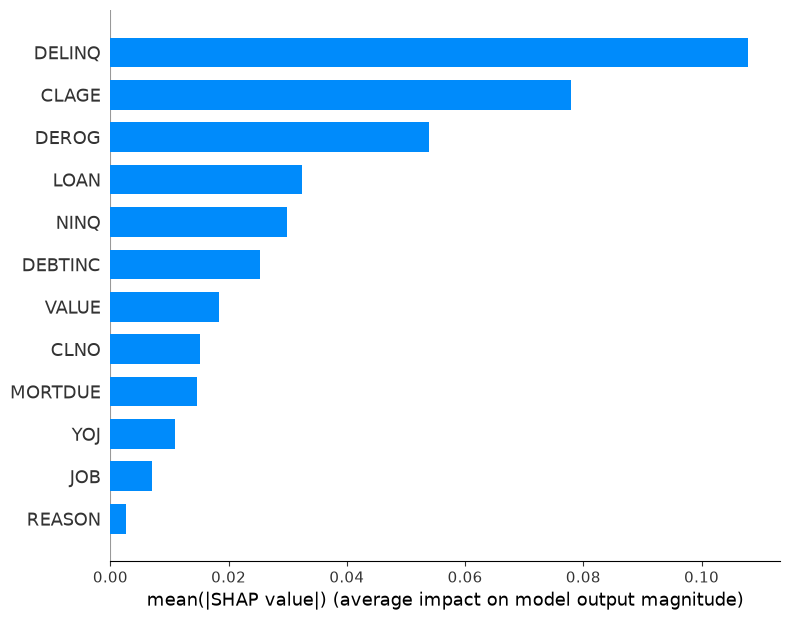

<Figure size 640x480 with 0 Axes>

In [307]:
# Creating a SHAP plot
import shap

explainer = shap.TreeExplainer(grid_search.best_estimator_)

shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values[:,:,1], X_test, plot_type='bar', 
    feature_names=X.columns)

plt.tight_layout()
plt.show()

The SHAP analysis reveals that DELINQ is by far the most influential feature in predicting loan default, with an average impact nearly double that of the second-ranked feature. This strongly confirms our EDA findings, where delinquent credit lines showed the clearest separation between defaulters and non-defaulters.

CLAGE ranks as the second most important feature, which is somewhat surprising given its moderate correlation with BAD (-0.17) observed in the heatmap. However, this can be explained by CLAGE's interaction with other variables — a borrower with a short credit history combined with high delinquency marks represents a significantly higher risk profile than either factor alone, and SHAP captures these interaction effects that simple correlation cannot.

DEROG ranks third, further confirming that credit behavior variables dominate the model's decision-making. LOAN, NINQ, and DEBTINC show moderate importance, while VALUE, CLNO, MORTDUE, and YOJ contribute minimally. JOB and REASON have the least impact on predictions, which aligns with our bivariate analysis where these categorical variables showed limited separation between defaulters and non-defaulters.

Notably, DEBTINC ranks lower than expected given its correlation with BAD (0.20), likely due to signal loss from its high missing value rate (21.26%) despite KNN imputation. These SHAP insights confirm that credit behavior history, specifically delinquency patterns and credit age, is the primary driver of default risk in this dataset, which is consistent with established lending principles.

In [308]:
# Export SHAP feature importance for Power BI
shap_importance = pd.DataFrame(
    {'Feature': X_test.columns,
    'Mean_absolute_shap': np.abs(shap_values[:, :, 1]).mean(axis=0)}
    ).sort_values('Mean_absolute_shap', ascending=False)
shap_importance.to_csv('shap_importance.csv', index=False)

### Wide GridSearch Tuning ###

To further improve recall performance, a wider hyperparameter search will be conducted with an expanded parameter grid, additionally incorporating max_features to control the number of features considered at each split. JOB and REASON features will be excluded from the feature set based on SHAP analysis, which identified them as the least impactful predictors. The search will test 216 parameter combinations across 5-fold cross validation, totalling 1,080 fits.

In [309]:
# Building a Wider Hyperparameter Tuning model

X = df.drop(columns=['BAD', 'JOB', 'REASON'])

X_train, X_test, y_train, y_test = train_test_split(X, y, 
    test_size=0.2, random_state=42, stratify=y)

In [310]:
# Using Wider Parameter Grid to extend the search

param_grid_wide = {
    'n_estimators': [100,200,300],
    'max_depth': [4,6,8,10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

grid_search_wide = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_wide,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search_wide.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [4, 6, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_au

In [311]:
#  Wide GridSearch Evaluation of train Set
model_performance_matrix(grid_search_wide, X_train, y_train)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,0.907928,0.72575,0.865405,0.789448,0.891964


In [312]:
# Wide GridSearch Evaluation of test set
model_performance_matrix(grid_search_wide, X_test, y_test)

,Accuracy,Precision,Recall,F1 Score,Roc_Auc
0,0.852349,0.615672,0.693277,0.652174,0.792655


The wider parameter grid search delivered the following test set results: Accuracy 85.2%, Precision 61.6%, Recall 69.3%, F1 Score 0.65, and ROC-AUC 0.79. The model correctly identifies approximately 7 out of every 10 actual defaulters, which represents a meaningful improvement over earlier tuning attempts. The train/test gap remains within an acceptable range, confirming reasonable generalization to unseen data. 

While precision of 61.6% indicates that some creditworthy borrowers may be incorrectly flagged as defaulters, in a lending context, missing a genuine defaulter carries a significantly higher financial cost than over-flagging a low-risk applicant for additional review.

#### Building the Comparison Table ####

In [313]:
# Model comparison table

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 
              'Decision Tree (Stratified)', 
              'Random Forest (Baseline)', 
              'RF Tuned Grid 1', 
              'RF Wider Grid (Final)'],
    'Accuracy': [0.8104, 0.9740, 0.9102, 0.8289, 0.8523],
    'Precision': [0.6639, 0.9559, 0.9712, 0.5586, 0.6157],
    'Recall': [0.2981, 0.9118, 0.5672, 0.6807, 0.6933],
    'F1 Score': [0.4115, 0.9333, 0.7162, 0.6136, 0.6522],
    'ROC_AUC': [0.6275, 0.9506, 0.7815, 0.7733, 0.7927]
})

comparison.set_index('Model', inplace=True)

comparison.style.highlight_max(axis=0, color='green')\
    .highlight_min(axis=0, color='salmon')\
    .format('{:.4f}')


,Accuracy,Precision,Recall,F1 Score,ROC_AUC
Model,,,,,
Logistic Regression,0.8104,0.6639,0.2981,0.4115,0.6275
Decision Tree (Stratified),0.9740,0.9559,0.9118,0.9333,0.9506
Random Forest (Baseline),0.9102,0.9712,0.5672,0.7162,0.7815
RF Tuned Grid 1,0.8289,0.5586,0.6807,0.6136,0.7733
RF Wider Grid (Final),0.8523,0.6157,0.6933,0.6522,0.7927


Based on the model comparison table, the RF Wider Grid (Final) model is the most suitable candidate for real-world deployment. While the Decision Tree (Stratified) achieved the highest scores across all metrics, these results are attributed to overfitting — the model memorized the training data rather than learning generalizable patterns, making its test performance an unreliable indicator of true predictive capability.

The RF Wider Grid model delivers the most honest and balanced performance on unseen data, with a Recall of 69.3% — the highest among all non-overfitted models — meaning it correctly identifies approximately 7 out of every 10 actual defaulters. 

In prediction loan defaults, Recall is the most critical metric, as failing to detect a genuine defaulter carries a significantly higher financial cost than occasionally flagging a low-risk applicant for additional review.

Logistic Regression, while interpretable, proved insufficient as a standalone model with a Recall of only 29.8% — catching fewer than 3 out of every 10 defaulters. The baseline Random Forest showed strong Precision (97.1%) but poor Recall (56.7%), confirming it was too conservative in flagging defaulters. 

The RF Wider Grid strikes the most practical balance between identifying defaulters and avoiding excessive false positives, making it the recommended final model.

In [314]:
# Export model comparison for Power BI
comparison.reset_index().to_csv('model_comparision.csv', index=False)

In [315]:
# Export final model test-set predicitons for Power BI
predictions=pd.DataFrame(
    {'Record_ID': X_test.index,
    'Actual': y_test.values,
    'Predicted': grid_search_wide.predict(X_test),
    'Prob_Default': grid_search_wide.predict_proba(X_test)[:,1]}
)
predictions.to_csv('predictions.csv', index=False)

### Final Conclusions ###

This project set out to build a classification model capable of predicting loan default for home equity line of credit applicants, using the HMEQ dataset of 5,960 borrowers. Through a comprehensive analytical process spanning exploratory data analysis, data preprocessing, and iterative model development, several key findings emerged.

From an EDA perspective, delinquency history (DELINQ) and major derogatory marks (DEROG) proved to be the strongest indicators of default risk, confirmed by both bivariate analysis and SHAP feature importance. Debt-to-income ratio (DEBTINC), credit age (CLAGE), and number of recent inquiries (NINQ) also demonstrated meaningful predictive power. Financial size variables such as loan amount, property value, and mortgage balance showed minimal separation between defaulters and non-defaulters, suggesting that how a borrower manages credit is far more predictive than how much credit they hold.

From a modeling perspective, the tuned Random Forest with wider parameter grid was selected as the final recommended model, achieving a test Recall of 69.3%, Accuracy of 85.2%, and ROC-AUC of 0.79. 

While there is room for further improvement, this model provides a reliable and generalizable foundation for automated credit risk scoring that aligns with the Equal Credit Opportunity Act's requirement for empirically derived and statistically sound credit decisions.

Future improvements could include exploring gradient boosting models such as XGBoost or LightGBM, applying more sophisticated feature engineering such as loan-to-value ratio, and collecting additional behavioral data such as payment history trends to further improve default detection.

### Business Recommendations ###

Recommendation 1 — Improve JOB Data Quality and Granularity

The JOB variable currently suffers from two significant limitations: a 4.68% missing value rate and overly broad categories, with 40% of borrowers classified as 'Other' — providing no meaningful employment information. While SHAP analysis identified JOB as a low-importance feature in the current model, this may be a data quality issue rather than a true reflection of employment's impact on default risk. Lenders should invest in collecting more granular and standardized employment data, as job type directly influences income stability and a borrower's ability to meet consistent monthly payment obligations. More detailed employment categorization may reveal hidden patterns that the current broad categories obscure.

Recommendation 2 — Prioritize Credit Behavior Over Financial Size in Underwriting

The analysis consistently demonstrated that how a borrower manages credit is far more predictive of default than how much credit they hold. DELINQ, DEROG, and CLAGE (all behavioral credit variables)  emerged as the top predictors of default risk. Lenders should therefore place greater weight on credit behavior history during the underwriting process. Specifically, any sign of delinquency should be treated as an early warning signal and monitored closely, even for borrowers with moderate income levels. Conversely, borrowers with long established credit histories and consistent payment records, even those with lower incomes applying for home improvement loans, should be recognized as lower-risk candidates, as their behavioral track record demonstrates financial responsibility over time.

Recommendation 3 — Implement a Real-Time Delinquency Monitoring System

Since DELINQ emerged as the single most important predictor of loan default, the bank should implement an automated early warning system that flags borrowers the moment a credit line becomes delinquent, defined as 30 to 60 days past due. Rather than relying solely on the model's prediction at the point of loan application, continuous post-approval monitoring would allow the bank to proactively intervene with at-risk borrowers through payment restructuring, counseling, or early collections, significantly reducing the rate of loans reaching full default status.

Recommendation 4 — Address DEBTINC Missing Data at the Application Stage

DEBTINC had the highest missing value rate in the dataset at 21.26%, yet it is one of the strongest predictors of default. This suggests that a significant number of loan applications were processed without a complete debt-to-income assessment - a gap in the underwriting process. The bank should make DEBTINC a mandatory field in the loan application, ensuring that no application proceeds without a verified debt-to-income calculation. This would not only improve future model performance but also strengthen underwriting quality and ECOA compliance.

Recommendation 5 — Deploy the Tuned Random Forest (Wider Grid) as the Primary Credit Scoring Model

Finally, based on the model comparison analysis, the Random Forest model with wider hyperparameter grid tuning is recommended for deployment as the primary loan default prediction tool. This model was trained exclusively on the most impactful features identified through SHAP analysis — DELINQ, CLAGE, DEROG, LOAN, NINQ, DEBTINC, VALUE, CLNO, MORTDUE, and YOJ — eliminating low-signal variables that introduced noise into earlier iterations. Among all non-overfitted models, it achieved the highest Recall score of 69.3%, meaning it correctly identifies approximately 7 out of every 10 actual defaulters on unseen data. Since the primary objective of this project is to minimize undetected loan defaults and reduce the bank's exposure to non-performing assets, Recall is the most critical success metric, and the RF Wider Grid model optimizes for exactly that. Its balanced performance across Accuracy (85.2), F1 Score (0.65), and ROC-AUC (0.79) further supports its suitability as a reliable and generalizable credit risk scoring tool that aligns with the bank's risk management objectives.

### Creating an SQL database ###

In [316]:
import sqlite3
conn = sqlite3.connect("hmeq.db")
raw = pd.read_csv("hmeq.csv")
raw.to_sql("hmeq_raw", conn, if_exists="replace",
           index=True, index_label="Record_ID")
pd.read_csv("predictions.csv").to_sql("predictions", conn,
           if_exists="replace", index=False)
conn.close()
print("hmeq.db built:", len(raw), "rows")

hmeq.db built: 5960 rows
